# Pre-Processing

In [1]:
import os
import json
from collections import Counter
from tqdm import tqdm

# --- CONFIGURATION ---
# Adjust these to point to your local unzipped directories
SOURCE_JSON_DIR = "./train/train/annos"   

# ==========================================
# STEP 1: Find the Top 5 Categories
# ==========================================
print(f"Scanning JSONs in: {SOURCE_JSON_DIR} to find top 5 categories...")
json_files = [f for f in os.listdir(SOURCE_JSON_DIR) if f.endswith('.json')]

if not json_files:
    raise FileNotFoundError(f"No JSON files found in {SOURCE_JSON_DIR}.")

category_counts = Counter()

# First pass: Count all categories to determine the top 5
for json_file in tqdm(json_files, desc="Counting Categories"):
    filepath = os.path.join(SOURCE_JSON_DIR, json_file)
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    for key, value in data.items():
        if key.startswith('item') and isinstance(value, dict):
            cat_name = value.get('category_name')
            if cat_name:
                category_counts[cat_name] += 1

top_5_tuples = category_counts.most_common(5)
top_5_classes = [cat for cat, count in top_5_tuples]

print(f"\n--- Top 5 Categories Identified ---")
for cat, count in top_5_tuples:
    print(f"{cat}: {count} total items")

Scanning JSONs in: ./train/train/annos to find top 5 categories...


Counting Categories: 100%|██████████| 191961/191961 [28:44<00:00, 111.29it/s]


--- Top 5 Categories Identified ---
short sleeve top: 71645 total items
trousers: 55387 total items
shorts: 36616 total items
long sleeve top: 36064 total items
skirt: 30835 total items


In [2]:
SOURCE_IMAGE_DIR = "./train/train/image"  
OUTPUT_JSON_PATH = "./master_train_annotations.json"

# ==========================================
# STEP 2: Extract Data and Calculate Weights
# ==========================================
print("\nExtracting annotations and calculating class weights for imbalance...")

master_annotations = {}
image_counts_per_class = {cls: 0 for cls in top_5_classes}
total_valid_images = 0

for json_file in tqdm(json_files, desc="Processing Annotations"):
    img_file = json_file.replace('.json', '.jpg')
    img_path = os.path.join(SOURCE_IMAGE_DIR, img_file)
    
    # Skip if the actual image file is missing locally
    if not os.path.exists(img_path):
        continue

    filepath = os.path.join(SOURCE_JSON_DIR, json_file)
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    filtered_items = []
    classes_in_this_image = set()
    
    for key, value in data.items():
        if key.startswith('item') and isinstance(value, dict):
            cat_name = value.get('category_name')
            
            if cat_name in top_5_classes:
                classes_in_this_image.add(cat_name)
                # Keep only fields needed for Classification, Detection, and Segmentation
                filtered_items.append({
                    "category_name": cat_name,
                    "category_id": value.get('category_id'),
                    "bounding_box": value.get('bounding_box'),
                    "segmentation": value.get('segmentation')
                })
                
    if filtered_items:
        # Use the absolute path as the key so the DataLoader can find it instantly
        master_annotations[img_path] = filtered_items
        total_valid_images += 1
        
        # Track how many IMAGES contain each class (needed for accurate BCE weights)
        for cat in classes_in_this_image:
            image_counts_per_class[cat] += 1

# ==========================================
# STEP 3: Save Output and Print Weights
# ==========================================
with open(OUTPUT_JSON_PATH, 'w') as f:
    json.dump(master_annotations, f)

print(f"\nSuccess! Consolidated annotations saved to: {OUTPUT_JSON_PATH}")
print(f"Total valid images retained: {total_valid_images}")

print("\n--- CRITICAL: Class Weights for PyTorch Loss Function ---")
# Formula for pos_weight in BCEWithLogitsLoss: (Total negative samples) / (Total positive samples)
pos_weights = []
for cat in top_5_classes:
    pos_count = image_counts_per_class[cat]
    neg_count = total_valid_images - pos_count
    weight = neg_count / pos_count if pos_count > 0 else 0
    pos_weights.append(round(weight, 4))
    
print(f"Classes order: {top_5_classes}")
print(f"pos_weight tensor: torch.tensor({pos_weights})")
print("Copy this tensor into your training script to handle class imbalance dynamically!")


Extracting annotations and calculating class weights for imbalance...


Processing Annotations: 100%|██████████| 191961/191961 [02:28<00:00, 1295.33it/s]



Success! Consolidated annotations saved to: ./master_train_annotations.json
Total valid images retained: 144174

--- CRITICAL: Class Weights for PyTorch Loss Function ---
Classes order: ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
pos_weight tensor: torch.tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077])
Copy this tensor into your training script to handle class imbalance dynamically!


# Classification

## EfficientNet-B2

### Transfer Learning

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models

print("Setting up Transfer Learning...")

# 1. Load pretrained model
model_transfer = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

# 2. Freeze all base layers
for param in model_transfer.parameters():
    param.requires_grad = False

# 3. Replace the final layer for our 5 categories (this layer defaults to requires_grad=True)
num_ftrs = model_transfer.classifier[1].in_features
model_transfer.classifier[1] = nn.Linear(num_ftrs, 5)

# 4. Optimizer only updates the final layer
optimizer_transfer = torch.optim.Adam(model_transfer.classifier.parameters(), lr=0.001)

Setting up Transfer Learning...


### Fine-tuning

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

print("Setting up Fine-Tuning...")

# 1. Load pretrained model
model_finetune = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

# 2. Leave all base layers UNFROZEN (requires_grad=True by default)

# 3. Replace the final layer for our 5 categories
num_ftrs = model_finetune.classifier[1].in_features
model_finetune.classifier[1] = nn.Linear(num_ftrs, 5)

# 4. Optimizer updates ALL layers, usually with a much smaller learning rate so we don't wreck the pretrained weights
optimizer_finetune = torch.optim.Adam(model_finetune.parameters(), lr=1e-4)

Setting up Fine-Tuning...


### Training from Scratch

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models

print("Setting up Training from Scratch...")

# 1. Load model architecture WITHOUT pretrained weights
model_scratch = models.efficientnet_b2(weights=None)

# 2. Base layers are unfrozen by default

# 3. Replace the final layer for our 5 categories
num_ftrs = model_scratch.classifier[1].in_features
model_scratch.classifier[1] = nn.Linear(num_ftrs, 5)

# 4. Optimizer updates ALL layers, usually with a standard learning rate
optimizer_scratch = torch.optim.Adam(model_scratch.parameters(), lr=0.001)

Setting up Training from Scratch...


### Dataset and Dataloader Setup

In [5]:
import os
import json
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

class ClothingMultiLabelDataset(Dataset):
    def __init__(self, json_path, transform=None):
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        
        # We need to extract the labels directly. 
        # Since our pre-processing saved a list of dicts per image, we parse it here.
        self.image_paths = list(self.data.keys())
        self.transform = transform
        
        # Define the exact order of classes you got from your previous script
        self.top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.top_5_classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        items = self.data[img_path]
        
        # Create multi-hot encoded vector [0., 0., 0., 0., 0.]
        labels = [0.0] * 5
        for item in items:
            cat_name = item['category_name']
            if cat_name in self.class_to_idx:
                labels[self.class_to_idx[cat_name]] = 1.0
                
        return image, torch.tensor(labels, dtype=torch.float32)

# Standard EfficientNet-B2 transforms
transform = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Initialize Dataset and DataLoader
# UPDATE this path to exactly where your master JSON is saved
train_dataset = ClothingMultiLabelDataset("./master_train_annotations.json", transform=transform)

# Your RTX 4060 can likely handle a batch size of 32 or 64. 
# num_workers speeds up data loading (use 4 or 8 depending on your CPU)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
print(f"Loaded {len(train_dataset)} training images.")

Loaded 144174 training images.


### Training Loop

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

def train_model(model, optimizer, criterion, train_loader, epochs=5, model_name="model"):
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        # Wrap loader in tqdm for a nice progress bar
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [{model_name}]")
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            
            # Calculate Binary Cross-Entropy Loss (sigmoid is applied internally) 
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
            
        epoch_loss = running_loss / len(train_loader)
        print(f"End of Epoch {epoch+1} - Average Loss: {epoch_loss:.4f}\n")
        
    print(f"--- Finished Training {model_name} ---")
    return model

# New function: train_model_all_epochs (using for Viva)
def train_model_all_epochs(model, optimizer, criterion, train_loader, epochs=5, model_name="model"):
    from tqdm import tqdm
    model.train()
    total_steps = epochs * len(train_loader)
    progress_bar = tqdm(total=total_steps, desc=f"Training {model_name} ({epochs} epochs)")
    
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.update(1)
            progress_bar.set_postfix({'epoch': epoch+1, 'loss': loss.item()})
        epoch_loss = running_loss / len(train_loader)
        print(f"End of Epoch {epoch+1} - Average Loss: {epoch_loss:.4f}\n")
    progress_bar.close()
    print(f"--- Finished Training {model_name} ---")
    return model


Training on: cuda


### Training

In [11]:
import gc
import torch
import torch.nn as nn
import torchvision.models as models

# --- IMPORTANT: Paste your exact pos_weight tensor from the previous script here ---
calculated_pos_weights = torch.tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077]).to(device) 

# Initialize loss function with class balancing 
criterion = nn.BCEWithLogitsLoss(pos_weight=calculated_pos_weights)

# ==========================================
# Strategy 1: Transfer Learning (Fastest) 
# ==========================================
print("\n=== Starting Transfer Learning ===")
model_transfer = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT).to(device)

# Freeze base layers 
for param in model_transfer.parameters():
    param.requires_grad = False

# Replace final layer (unfrozen by default) 
num_ftrs = model_transfer.classifier[1].in_features
model_transfer.classifier[1] = nn.Linear(num_ftrs, 5).to(device)

# Optimizer ONLY updates the classifier 
optimizer_transfer = torch.optim.Adam(model_transfer.classifier[1].parameters(), lr=0.001)

# Train the model
model_transfer = train_model_all_epochs(model_transfer, optimizer_transfer, criterion, train_loader, epochs=3, model_name="Transfer_Learning")

# Save, Delete, and Clear GPU Memory
torch.save(model_transfer.state_dict(), "efficientnet_transfer.pth")
del model_transfer, optimizer_transfer
gc.collect()
torch.cuda.empty_cache()
print("Saved Transfer Learning model to disk and cleared GPU memory.")


=== Starting Transfer Learning ===



=== Starting Transfer Learning ===


Training Transfer_Learning (3 epochs):   0%|          | 14/13518 [00:06<1:43:28,  2.18it/s, epoch=1, loss=0.906]


=== Starting Transfer Learning ===


Training Transfer_Learning (3 epochs):   0%|          | 14/13518 [00:06<1:43:28,  2.18it/s, epoch=1, loss=0.906]

KeyboardInterrupt: 

In [14]:
# ==========================================
# Strategy 2: Fine-Tuning 
# ==========================================
print("\n=== Starting Fine-Tuning ===")
model_finetune = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT).to(device)
num_ftrs = model_finetune.classifier[1].in_features
model_finetune.classifier[1] = nn.Linear(num_ftrs, 5).to(device)

# Optimizer updates ALL layers, but with a smaller learning rate
optimizer_finetune = torch.optim.Adam(model_finetune.parameters(), lr=1e-4)

# Train the model
model_finetune = train_model_all_epochs(model_finetune, optimizer_finetune, criterion, train_loader, epochs=5, model_name="Fine_Tuning")

# Save, Delete, and Clear GPU Memory
torch.save(model_finetune.state_dict(), "efficientnet_finetune.pth")
del model_finetune, optimizer_finetune
gc.collect()
torch.cuda.empty_cache()
print("Saved Fine-Tuning model to disk and cleared GPU memory.")


=== Starting Fine-Tuning ===


Training Fine_Tuning (5 epochs):   0%|          | 5/22530 [00:03<4:02:14,  1.55it/s, epoch=1, loss=0.952]


=== Starting Fine-Tuning ===


Training Fine_Tuning (5 epochs):   0%|          | 5/22530 [00:03<4:02:14,  1.55it/s, epoch=1, loss=0.952]

KeyboardInterrupt: 

In [18]:
# ==========================================
# Strategy 3: Training from Scratch (Slowest)
# ==========================================
print("\n=== Starting Training from Scratch ===")
# No pre-trained weights 
model_scratch = models.efficientnet_b2(weights=None).to(device)
num_ftrs = model_scratch.classifier[1].in_features
model_scratch.classifier[1] = nn.Linear(num_ftrs, 5).to(device)

# Optimizer updates ALL layers with standard learning rate
optimizer_scratch = torch.optim.Adam(model_scratch.parameters(), lr=0.001)

# Train the model
model_scratch = train_model_all_epochs(model_scratch, optimizer_scratch, criterion, train_loader, epochs=10, model_name="Scratch")

# Save, Delete, and Clear GPU Memory
torch.save(model_scratch.state_dict(), "efficientnet_scratch.pth")
del model_scratch, optimizer_scratch
gc.collect()
torch.cuda.empty_cache()
print("Saved Scratch model to disk and cleared GPU memory.")


=== Starting Training from Scratch ===


Training Scratch (10 epochs):   0%|          | 13/45060 [00:08<7:45:39,  1.61it/s, epoch=1, loss=1.02] 


=== Starting Training from Scratch ===


Training Scratch (10 epochs):   0%|          | 13/45060 [00:08<7:45:39,  1.61it/s, epoch=1, loss=1.02] 

KeyboardInterrupt: 

### Metrics

Loaded 23741 validation images.

Evaluating Transfer Learning Model...


Running Inference: 100%|██████████| 371/371 [09:11<00:00,  1.49s/it]



--- Results for Transfer Learning Model ---
[short sleeve top] Precision: 0.7350 | Recall: 0.6976 | F1: 0.7158
[trousers] Precision: 0.7121 | Recall: 0.7921 | F1: 0.7500
[shorts] Precision: 0.3709 | Recall: 0.7234 | F1: 0.4904
[long sleeve top] Precision: 0.4578 | Recall: 0.7490 | F1: 0.5683
[skirt] Precision: 0.5987 | Recall: 0.7427 | F1: 0.6630

Macro-Averaged F1: 0.6375
Micro-Averaged F1: 0.6565
[short sleeve top] AUC: 0.7858
[trousers] AUC: 0.8777
[shorts] AUC: 0.8159
[long sleeve top] AUC: 0.8024
[skirt] AUC: 0.8660


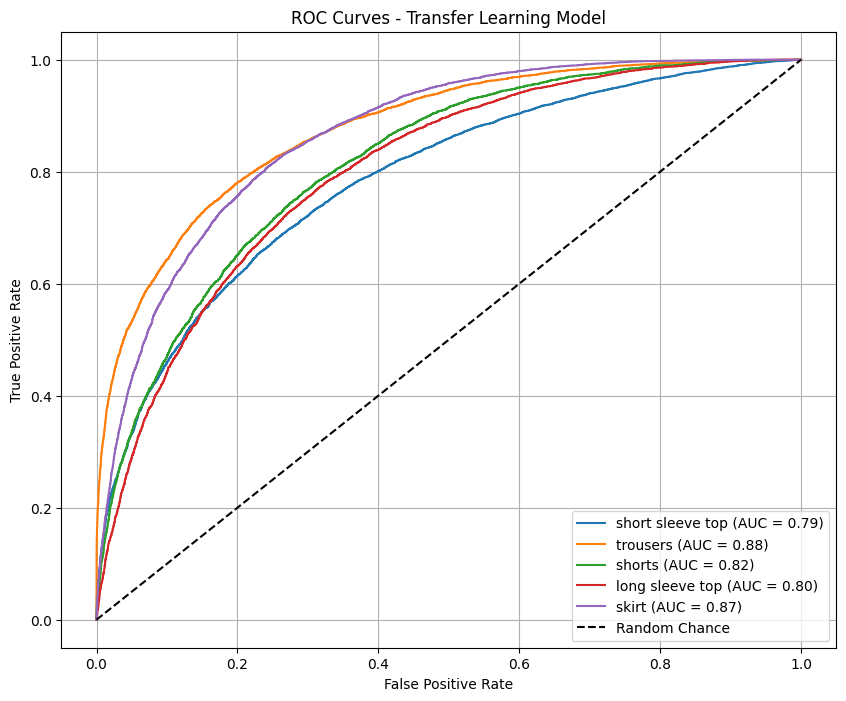


Evaluating Fine-Tuned Model...


Running Inference: 100%|██████████| 371/371 [04:27<00:00,  1.39it/s]


--- Results for Fine-Tuned Model ---
[short sleeve top] Precision: 0.9284 | Recall: 0.8807 | F1: 0.9039
[trousers] Precision: 0.8774 | Recall: 0.9484 | F1: 0.9115
[shorts] Precision: 0.7866 | Recall: 0.8739 | F1: 0.8280
[long sleeve top] Precision: 0.7812 | Recall: 0.8900 | F1: 0.8320
[skirt] Precision: 0.8826 | Recall: 0.8968 | F1: 0.8896

Macro-Averaged F1: 0.8730
Micro-Averaged F1: 0.8834
[short sleeve top] AUC: 0.9664
[trousers] AUC: 0.9811
[shorts] AUC: 0.9734
[long sleeve top] AUC: 0.9646
[skirt] AUC: 0.9786


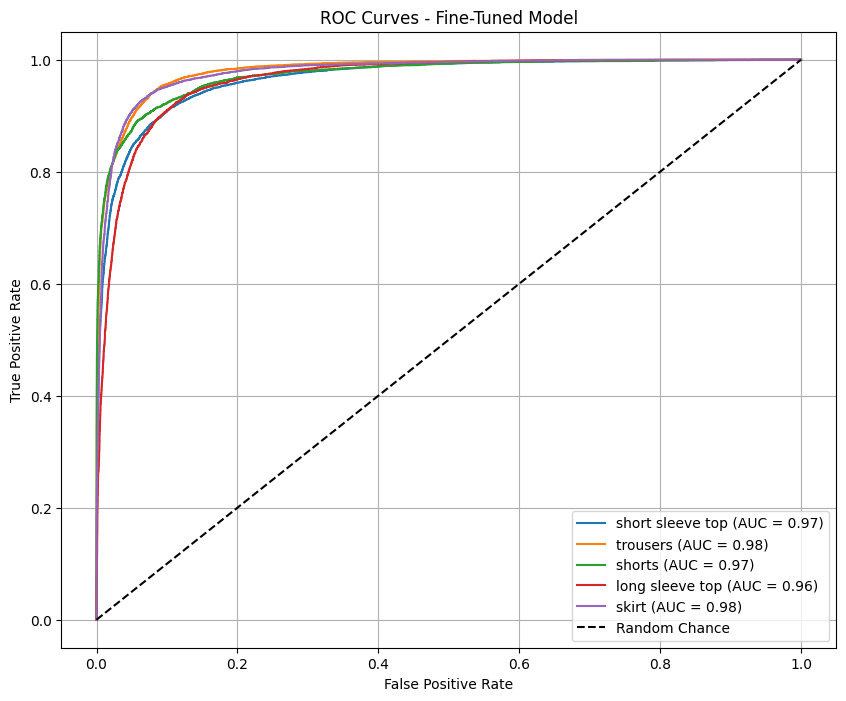


Evaluating From-Scratch Model...


Running Inference: 100%|██████████| 371/371 [03:48<00:00,  1.62it/s]


--- Results for From-Scratch Model ---
[short sleeve top] Precision: 0.8711 | Recall: 0.8518 | F1: 0.8613
[trousers] Precision: 0.8241 | Recall: 0.9447 | F1: 0.8803
[shorts] Precision: 0.6657 | Recall: 0.8125 | F1: 0.7318
[long sleeve top] Precision: 0.6500 | Recall: 0.8389 | F1: 0.7325
[skirt] Precision: 0.7535 | Recall: 0.8634 | F1: 0.8047

Macro-Averaged F1: 0.8021
Micro-Averaged F1: 0.8204
[short sleeve top] AUC: 0.9359
[trousers] AUC: 0.9696
[shorts] AUC: 0.9376
[long sleeve top] AUC: 0.9261
[skirt] AUC: 0.9494


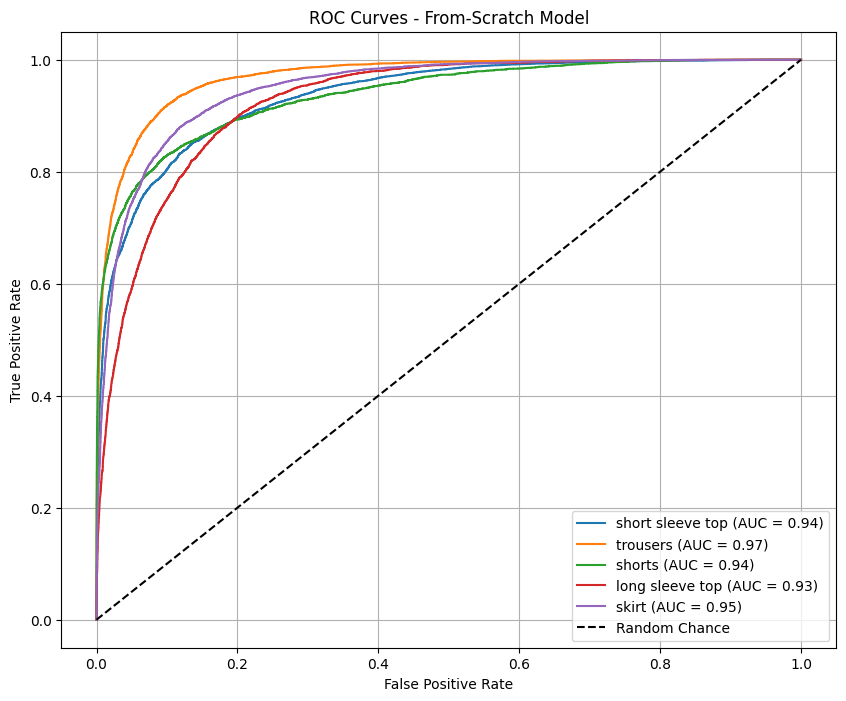

In [1]:
import os
import json
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --- 1. Validation Dataset Setup ---
class ValidationDataset(Dataset):
    def __init__(self, json_dir, image_dir, transform=None):
        self.json_dir = json_dir
        self.image_dir = image_dir
        self.transform = transform
        self.json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
        
        # Hardcode the exact order used during training
        self.top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.top_5_classes)}

    def __len__(self):
        return len(self.json_files)

    def __getitem__(self, idx):
        json_file = self.json_files[idx]
        img_file = json_file.replace('.json', '.jpg')
        
        img_path = os.path.join(self.image_dir, img_file)
        json_path = os.path.join(self.json_dir, json_file)
        
        # Open image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
            
        # Parse JSON for ground truth labels
        with open(json_path, 'r') as f:
            data = json.load(f)
            
        labels = [0.0] * 5
        for key, value in data.items():
            if key.startswith('item') and isinstance(value, dict):
                cat_name = value.get('category_name')
                if cat_name in self.class_to_idx:
                    labels[self.class_to_idx[cat_name]] = 1.0
                    
        return image, torch.tensor(labels, dtype=torch.float32)

# Use the exact same transforms used in training!
transform = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_dataset = ValidationDataset(
    json_dir="./trimmed_dataset/validation/annos", 
    image_dir="./trimmed_dataset/validation/image", 
    transform=transform
)
# We can use a larger batch size for validation since we aren't storing gradients
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f"Loaded {len(val_dataset)} validation images.")

# --- 2. Evaluation Function ---
def evaluate_model(model, dataloader, device, model_name):
    print(f"\nEvaluating {model_name}...")
    model.eval()
    
    all_targets = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad(): # Crucial: prevents memory tracking during inference
        for images, labels in tqdm(dataloader, desc="Running Inference"):
            images = images.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Apply Sigmoid to get probabilities between 0 and 1
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            # Threshold at 0.5 for binary predictions
            preds = (probs > 0.5).astype(int)
            
            all_probabilities.extend(probs)
            all_predictions.extend(preds)
            all_targets.extend(labels.numpy())
            
    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    
    classes = val_dataset.top_5_classes
    
    # --- Metrics Calculation ---
    print(f"\n--- Results for {model_name} ---")
    
    # 1. Per-Class Precision, Recall, F1 
    precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average=None, zero_division=0)
    for i, cls in enumerate(classes):
        print(f"[{cls}] Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f}")
        
    # 2. Macro and Micro F1-Scores 
    _, _, macro_f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average='macro', zero_division=0)
    _, _, micro_f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average='micro', zero_division=0)
    print(f"\nMacro-Averaged F1: {macro_f1:.4f}")
    print(f"Micro-Averaged F1: {micro_f1:.4f}")
    
    # 3. ROC and AUC per class 
    plt.figure(figsize=(10, 8))
    for i, cls in enumerate(classes):
        # Calculate AUC
        auc_score = roc_auc_score(all_targets[:, i], all_probabilities[:, i])
        print(f"[{cls}] AUC: {auc_score:.4f}")
        
        # Calculate ROC Curve
        fpr, tpr, _ = roc_curve(all_targets[:, i], all_probabilities[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc_score:.2f})")
        
    # Plotting formatting
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# --- 3. Load Models and Run ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_and_eval(weights_path, model_name):
    # Initialize skeleton
    model = models.efficientnet_b2(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 5)
    
    # Load weights
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    model = model.to(device)
    
    # Evaluate
    evaluate_model(model, val_loader, device, model_name)
    
    # Clean up GPU memory
    del model
    torch.cuda.empty_cache()

# Execute for all three saved models
try:
    load_and_eval("efficientnet_transfer.pth", "Transfer Learning Model")
    load_and_eval("efficientnet_finetune.pth", "Fine-Tuned Model")
    load_and_eval("efficientnet_scratch.pth", "From-Scratch Model") 
except FileNotFoundError as e:
    print(f"\nError: Could not find model weights. Make sure you are in the correct directory! ({e})")

## MobileNet

### Imports and Setup

In [19]:
import torch.nn as nn

# =========================
# MobileNet Imports
# =========================
from torchvision.models import mobilenet_v3_large
from torchvision.models import MobileNet_V3_Large_Weights

# -------------------------
# Fine-Tuning
# -------------------------
def get_mobilenet_finetune(num_classes=5):
    model = mobilenet_v3_large(
        weights=MobileNet_V3_Large_Weights.DEFAULT
    )

    # Train entire network
    model.classifier[3] = nn.Linear(1280, num_classes)
    return model


# -------------------------
# Training From Scratch
# -------------------------
def get_mobilenet_scratch(num_classes=5):
    model = mobilenet_v3_large(weights=None)
    model.classifier[3] = nn.Linear(1280, num_classes)

    return model

### Dataset Loader Setup

In [20]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class ClothingClassificationDataset(Dataset):
    def __init__(self, annotations_path, image_dir, label_map_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        
        # 1. Load your pre-defined Label Map
        print(f"Loading label map from {label_map_path}...")
        with open(label_map_path, 'r') as f:
            self.class_to_idx = json.load(f)
        self.num_classes = len(self.class_to_idx)
        
        # 2. Load the training annotations
        print(f"Loading annotations from {annotations_path}...")
        with open(annotations_path, 'r') as f:
            self.data = json.load(f)
            
        self.image_paths = list(self.data.keys())

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        img_name = os.path.basename(img_path)
        full_img_path = os.path.join(self.image_dir, img_name)
        img_pil = Image.open(full_img_path).convert("RGB")
        
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = T.ToTensor()(img_pil)
            
        # Initialize a tensor of zeros matching the length of your label map
        label_vector = torch.zeros(self.num_classes, dtype=torch.float32)
        annotations = self.data.get(img_path, [])
        
        for anno in annotations:
            cat_name = anno.get('category_name')
            if cat_name in self.class_to_idx:
                class_idx = self.class_to_idx[cat_name]
                label_vector[class_idx] = 1.0 
                
        return img_tensor, label_vector

### Training Loop (Finetune)

In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# =========================
# Device & Directory Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SAVE_DIR = "./MobileNet"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Dataset
# =========================
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pass all 3 paths here
dataset = ClothingClassificationDataset(
    annotations_path="./balanced_train_annotations.json", 
    image_dir="./train/train/image",
    label_map_path="./label_map.json",
    transform=train_transforms
)

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0, # Keeps Windows from deadlocking
    pin_memory=True
)

# =========================
# Model, Loss & Optimizer
# =========================
model = get_mobilenet_finetune()
model = model.to(device)

pos_weight = torch.tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler('cuda')

# =========================
# Training Loop (Single Bar)
# =========================
EPOCHS = 5
total_steps = EPOCHS * len(train_loader)

# Initialize the single progress bar outside the epoch loop
progress_bar = tqdm(total=total_steps, desc="Fine-Tuning MobileNet")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        
        # Update the description and advance the bar by 1 step
        progress_bar.set_description(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss.item():.4f}")
        progress_bar.update(1)

    epoch_loss = running_loss / len(train_loader)
    
    # Use tqdm.write so it prints neatly above the progress bar without breaking it
    tqdm.write(f"\nEnd of Epoch {epoch+1} | Average Loss: {epoch_loss:.4f}")

    checkpoint_path = os.path.join(SAVE_DIR, f"mobilenet_finetune_epoch_{epoch+1}.pth")
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": epoch_loss
    }, checkpoint_path)
    
    torch.cuda.empty_cache()

progress_bar.close()
print("\nFine-Tuning Complete!")

Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


Training Scratch (10 epochs):   0%|          | 13/45060 [09:08<528:06:02, 42.20s/it, epoch=1, loss=1.02]


Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


Training Scratch (10 epochs):   0%|          | 13/45060 [09:08<528:06:02, 42.20s/it, epoch=1, loss=1.02]


...

Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


Training Scratch (10 epochs):   0%|          | 13/45060 [09:08<528:06:02, 42.20s/it, epoch=1, loss=1.02]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\Darsh Veer Singh/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:02<00:00, 10.1MB/s]
Epoch 1/5 | Loss: 0.9735:   0%|          | 25/22330 [00:15<1:32:12,  4.03it/s]

KeyboardInterrupt: 

### Training Loop (Scratch)

In [29]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# =========================
# Device & Directory Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SAVE_DIR = "./models"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Dataset
# =========================
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ClothingClassificationDataset(
    annotations_path="./balanced_train_annotations.json", 
    image_dir="./train/train/image",
    label_map_path="./label_map.json",
    transform=train_transforms
)

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# =========================
# Model, Loss & Optimizer
# =========================
model = get_mobilenet_scratch()
model = model.to(device)

pos_weight = torch.tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler('cuda')

# =========================
# Training Loop (Single Bar)
# =========================
EPOCHS = 10
total_steps = EPOCHS * len(train_loader)

progress_bar = tqdm(total=total_steps, desc="Training MobileNet (Scratch)")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        
        progress_bar.set_description(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss.item():.4f}")
        progress_bar.update(1)

    epoch_loss = running_loss / len(train_loader)
    
    tqdm.write(f"\nEnd of Epoch {epoch+1} | Average Loss: {epoch_loss:.4f}")

    checkpoint_path = os.path.join(SAVE_DIR, f"mobilenet_scratch_epoch_{epoch+1}.pth")
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": epoch_loss
    }, checkpoint_path)
    
    torch.cuda.empty_cache()

progress_bar.close()
print("\nScratch Training Complete!")

c:\Users\Darsh Veer Singh\OneDrive - iiit-b\Sem 6\AID825 - Visual Recognition\Mini Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


c:\Users\Darsh Veer Singh\OneDrive - iiit-b\Sem 6\AID825 - Visual Recognition\Mini Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


Epoch 1/10 | Loss: 0.9930:   0%|          | 30/44660 [00:06<2:51:02,  4.35it/s]

c:\Users\Darsh Veer Singh\OneDrive - iiit-b\Sem 6\AID825 - Visual Recognition\Mini Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...


Epoch 1/10 | Loss: 0.9930:   0%|          | 30/44660 [00:06<2:51:02,  4.35it/s]

KeyboardInterrupt: 

### Metrics

Loaded 23741 validation images.

Evaluating MobileNet (Fine-Tuned)...


Running Inference: 100%|██████████| 371/371 [07:18<00:00,  1.18s/it]



--- Results for MobileNet (Fine-Tuned) ---
[short sleeve top] Precision: 0.7730 | Recall: 0.1302 | F1: 0.2229
[trousers] Precision: 0.6415 | Recall: 0.4403 | F1: 0.5222
[shorts] Precision: 0.6053 | Recall: 0.2030 | F1: 0.3040
[long sleeve top] Precision: 0.3044 | Recall: 0.5757 | F1: 0.3982
[skirt] Precision: 0.5059 | Recall: 0.3080 | F1: 0.3829

Macro-Averaged F1: 0.3661
Micro-Averaged F1: 0.3789
[short sleeve top] AUC: 0.6303
[trousers] AUC: 0.7145
[shorts] AUC: 0.7135
[long sleeve top] AUC: 0.6016
[skirt] AUC: 0.6797


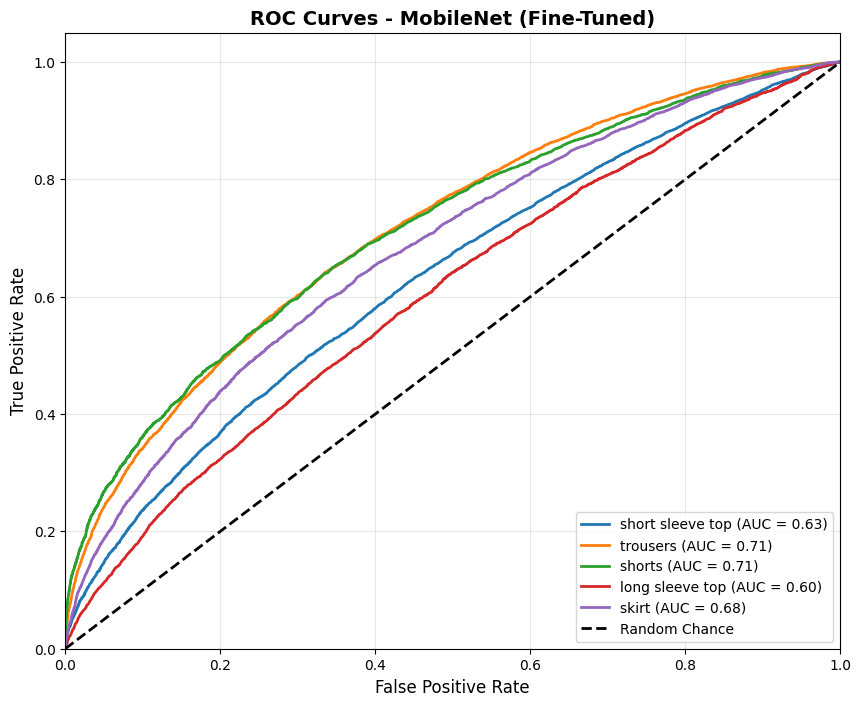


Evaluating MobileNet (From Scratch)...


Running Inference: 100%|██████████| 371/371 [03:50<00:00,  1.61it/s]



--- Results for MobileNet (From Scratch) ---
[short sleeve top] Precision: 0.6301 | Recall: 0.6568 | F1: 0.6432
[trousers] Precision: 0.5289 | Recall: 0.8724 | F1: 0.6586
[shorts] Precision: 0.3882 | Recall: 0.4101 | F1: 0.3989
[long sleeve top] Precision: 0.3780 | Recall: 0.4645 | F1: 0.4168
[skirt] Precision: 0.5644 | Recall: 0.4050 | F1: 0.4716

Macro-Averaged F1: 0.5178
Micro-Averaged F1: 0.5641
[short sleeve top] AUC: 0.6764
[trousers] AUC: 0.7847
[shorts] AUC: 0.7068
[long sleeve top] AUC: 0.6663
[skirt] AUC: 0.7455


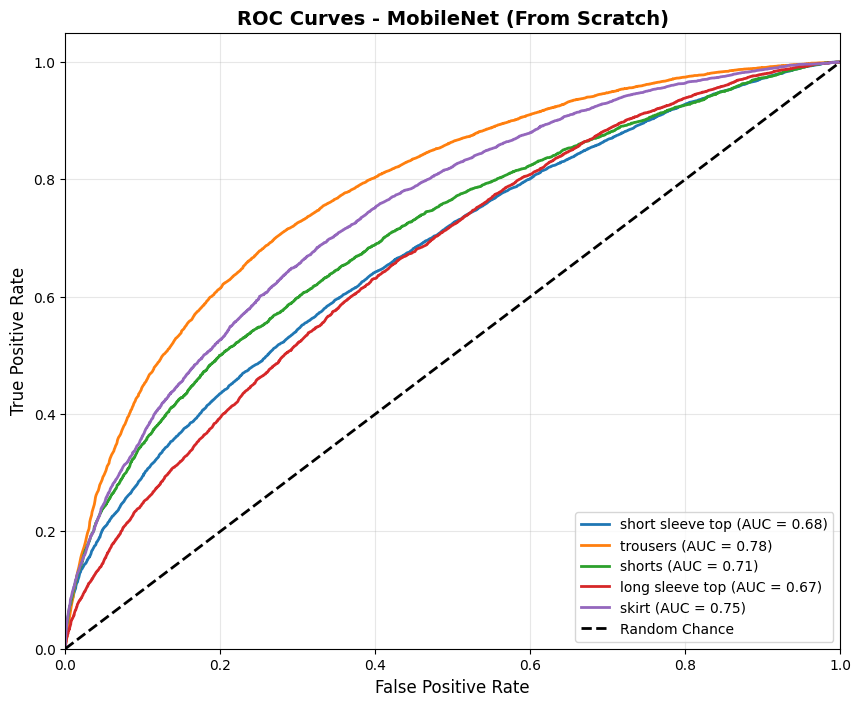

In [12]:
import os
import json
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --- 1. Validation Dataset Setup ---
class ValidationDataset(Dataset):
    def __init__(self, json_dir, image_dir, transform=None):
        self.json_dir = json_dir
        self.image_dir = image_dir
        self.transform = transform
        self.json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
        
        self.top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.top_5_classes)}

    def __len__(self):
        return len(self.json_files)

    def __getitem__(self, idx):
        json_file = self.json_files[idx]
        img_file = json_file.replace('.json', '.jpg')
        
        img_path = os.path.join(self.image_dir, img_file)
        json_path = os.path.join(self.json_dir, json_file)
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
            
        with open(json_path, 'r') as f:
            data = json.load(f)
            
        labels = [0.0] * 5
        for key, value in data.items():
            if key.startswith('item') and isinstance(value, dict):
                cat_name = value.get('category_name')
                if cat_name in self.class_to_idx:
                    labels[self.class_to_idx[cat_name]] = 1.0
                    
        return image, torch.tensor(labels, dtype=torch.float32)

# MobileNet uses 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_dataset = ValidationDataset(
    json_dir="./trimmed_dataset/validation/annos", 
    image_dir="./trimmed_dataset/validation/image", 
    transform=transform
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f"Loaded {len(val_dataset)} validation images.")


# --- 2. MobileNet Architecture Builders ---
def get_mobilenet_finetune(num_classes=5):
    # Load MobileNetV3 Large
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
    # MobileNetV3 has a more complex head; the final linear layer is at index 3
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

def get_mobilenet_scratch(num_classes=5):
    # Load MobileNetV3 Large with NO weights
    model = models.mobilenet_v3_large(weights=None)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

# --- 3. Evaluation Function ---
def evaluate_model(model, dataloader, device, model_name):
    print(f"\nEvaluating {model_name}...")
    model.eval()
    
    all_targets = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Running Inference"):
            images = images.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probabilities.extend(probs)
            all_predictions.extend(preds)
            all_targets.extend(labels.numpy())
            
    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    
    classes = val_dataset.top_5_classes
    
    # --- Metrics Calculation ---
    print(f"\n--- Results for {model_name} ---")
    
    precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average=None, zero_division=0)
    for i, cls in enumerate(classes):
        print(f"[{cls}] Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f}")
        
    _, _, macro_f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average='macro', zero_division=0)
    _, _, micro_f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average='micro', zero_division=0)
    print(f"\nMacro-Averaged F1: {macro_f1:.4f}")
    print(f"Micro-Averaged F1: {micro_f1:.4f}")
    
    # --- ROC Curves ---
    plt.figure(figsize=(10, 8))
    for i, cls in enumerate(classes):
        auc_score = roc_auc_score(all_targets[:, i], all_probabilities[:, i])
        print(f"[{cls}] AUC: {auc_score:.4f}")
        
        fpr, tpr, _ = roc_curve(all_targets[:, i], all_probabilities[:, i])
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc_score:.2f})")
        
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 4. Load Models and Run ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_and_eval_mobilenet(weights_path, model_name, mode):
    # Initialize MobileNet Skeleton
    if mode == "finetune":
        model = get_mobilenet_finetune()
    else:
        model = get_mobilenet_scratch()
    
    # Safely load the dictionary
    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict)
    
    model = model.to(device)
    
    # Evaluate
    evaluate_model(model, val_loader, device, model_name)
    
    # Clean up GPU memory
    del model
    torch.cuda.empty_cache()

# Execute MobileNet models
try:
    load_and_eval_mobilenet("./MobileNet/mobilenet_finetune_epoch_5.pth", "MobileNet (Fine-Tuned)", "finetune")
    load_and_eval_mobilenet("./MobileNet/mobilenet_scratch_epoch_10.pth", "MobileNet (From Scratch)", "scratch")
except FileNotFoundError as e:
    print(f"\nError: Could not find model weights. ({e})")

## ResNet-50

### Imports and Setup

In [2]:
import torch.nn as nn

# =========================
# ResNet50 Imports
# =========================
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

# -------------------------
# Fine-Tuning
# -------------------------
def get_resnet50_finetune(num_classes=5):
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    # Train entire network
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


# -------------------------
# Training From Scratch
# -------------------------
def get_resnet50_scratch(num_classes=5):
    model = resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

### Dataset Loader

In [3]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class ClothingClassificationDataset(Dataset):
    def __init__(self, annotations_path, image_dir, label_map_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        
        # 1. Load your pre-defined Label Map
        print(f"Loading label map from {label_map_path}...")
        with open(label_map_path, 'r') as f:
            self.class_to_idx = json.load(f)
        self.num_classes = len(self.class_to_idx)
        
        # 2. Load the training annotations
        print(f"Loading annotations from {annotations_path}...")
        with open(annotations_path, 'r') as f:
            self.data = json.load(f)
            
        self.image_paths = list(self.data.keys())

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        img_name = os.path.basename(img_path)
        full_img_path = os.path.join(self.image_dir, img_name)
        img_pil = Image.open(full_img_path).convert("RGB")
        
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = T.ToTensor()(img_pil)
            
        # Initialize a tensor of zeros matching the length of your label map
        label_vector = torch.zeros(self.num_classes, dtype=torch.float32)
        annotations = self.data.get(img_path, [])
        
        for anno in annotations:
            cat_name = anno.get('category_name')
            if cat_name in self.class_to_idx:
                class_idx = self.class_to_idx[cat_name]
                label_vector[class_idx] = 1.0 
                
        return img_tensor, label_vector

### Training Loop (Finetune)

In [4]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import f1_score

# =========================
# Device & Directory Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SAVE_DIR = "./ResNet"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Dataset & Splits
# =========================
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading dataset...")
# Assuming ClothingClassificationDataset is defined above in your notebook
full_dataset = ClothingClassificationDataset(
    annotations_path="./balanced_train_annotations.json", 
    image_dir="./train/train/image",
    label_map_path="./label_map.json",
    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train size: {len(train_data)} | Val size: {len(val_data)}")

# =========================
# Model Setup (TRUE Fine-Tune)
# =========================
print("Loading Pre-trained ResNet50...")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# All layers remain unfrozen so the entire network can adapt to clothing
model.fc = nn.Linear(model.fc.in_features, full_dataset.num_classes)
model = model.to(device)

# =========================
# Loss & Optimizer
# =========================
pos_weights = torch.tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler('cuda')

# =========================
# Training Loop
# =========================
EPOCHS = 5

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0

    # Create a fresh, single-line progress bar for THIS epoch's batches
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True, dynamic_ncols=True)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        
        # Use postfix instead of set_description to cleanly update live stats
        pbar.set_postfix({'Train Loss': f"{loss.item():.4f}"})

    avg_train_loss = running_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    all_preds, all_labels = [], []

    # Silent inner loop for validation
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                preds = torch.sigmoid(model(images))
                
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    y_true = np.vstack(all_labels)
    y_pred = (np.vstack(all_preds) > 0.5).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Safely print the final epoch summary WITHOUT breaking the progress bar
    tqdm.write(f"✅ End of Epoch {epoch+1} | Avg Train Loss: {avg_train_loss:.4f} | Val Macro F1: {f1:.4f}\n")

    # --- SAVE & CLEANUP ---
    checkpoint_path = os.path.join(SAVE_DIR, f"resnet50_TRUE_finetune_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_train_loss,
        'f1': f1
    }, checkpoint_path)

    gc.collect()
    torch.cuda.empty_cache()

print("True Fine-Tuning Complete!")

Using device: cuda
Loading dataset...
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...
Train size: 57154 | Val size: 14289
Loading Pre-trained ResNet50...


Epoch 1/5: 100%|██████████| 3573/3573 [16:26<00:00,  3.62it/s, Train Loss=0.4109]


✅ End of Epoch 1 | Avg Train Loss: 0.4613 | Val Macro F1: 0.8396



Epoch 2/5: 100%|██████████| 3573/3573 [14:59<00:00,  3.97it/s, Train Loss=0.1509]


✅ End of Epoch 2 | Avg Train Loss: 0.3147 | Val Macro F1: 0.8628



...

✅ End of Epoch 3 | Avg Train Loss: 0.2497 | Val Macro F1: 0.8624



Epoch 4/5: 100%|██████████| 3573/3573 [16:54<00:00,  3.52it/s, Train Loss=0.8249]


✅ End of Epoch 4 | Avg Train Loss: 0.1980 | Val Macro F1: 0.8686



Epoch 5/5: 100%|██████████| 3573/3573 [18:17<00:00,  3.26it/s, Train Loss=0.0691]


✅ End of Epoch 5 | Avg Train Loss: 0.1634 | Val Macro F1: 0.8720

True Fine-Tuning Complete!


### Training Loop (Scratch)

In [8]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import f1_score

# =========================
# Device & Directory Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SAVE_DIR = "./ResNet"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Dataset & Splits
# =========================
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading dataset...")
full_dataset = ClothingClassificationDataset(
    annotations_path="./balanced_train_annotations.json", 
    image_dir="./train/train/image",
    label_map_path="./label_map.json",
    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train size: {len(train_data)} | Val size: {len(val_data)}")

# =========================
# Model Setup (Scratch)
# =========================
print("Loading ResNet50 (From Scratch)...")
model = models.resnet50(weights=None) # NO pretrained weights

# Replace classification head
model.fc = nn.Linear(model.fc.in_features, full_dataset.num_classes)
model = model.to(device)

# =========================
# Loss & Optimizer
# =========================
pos_weights = torch.tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# Note: Training from scratch requires a higher learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-3) 
scaler = torch.amp.GradScaler('cuda')

# =========================
# Training Loop
# =========================
EPOCHS = 10
total_steps = EPOCHS * len(train_loader)
progress_bar = tqdm(total=total_steps, desc="Training ResNet50 (Scratch)")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        
        progress_bar.set_description(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {loss.item():.4f}")
        progress_bar.update(1)

    avg_train_loss = running_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                preds = torch.sigmoid(model(images))
                
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    y_true = np.vstack(all_labels)
    y_pred = (np.vstack(all_preds) > 0.5).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Print safely above the progress bar
    tqdm.write(f"\nEnd of Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val F1: {f1:.4f}")

    # --- SAVE & CLEANUP ---
    checkpoint_path = os.path.join(SAVE_DIR, f"resnet50_scratch_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_train_loss,
        'f1': f1
    }, checkpoint_path)

    gc.collect()
    torch.cuda.empty_cache()

progress_bar.close()
print("🎉 Scratch Training Complete!")

Using device: cuda
Loading dataset...
Loading label map from ./label_map.json...
Loading annotations from ./balanced_train_annotations.json...
Train size: 57154 | Val size: 14289
Loading ResNet50 (From Scratch)...


Epoch 1/10 | Train Loss: 1.0977:   0%|          | 15/35730 [00:10<6:47:37,  1.46it/s]
Epoch 1/10 | Train Loss: 1.3398:   0%|          | 19/35730 [00:05<2:34:20,  3.86it/s]

KeyboardInterrupt: 

### Metrics

Loaded 23741 validation images.

Evaluating ResNet50 (Fine-Tuned)...


Running Inference: 100%|██████████| 371/371 [08:29<00:00,  1.37s/it]



--- Results for ResNet50 (Fine-Tuned) ---
[short sleeve top] Precision: 0.8965 | Recall: 0.8549 | F1: 0.8752
[trousers] Precision: 0.9019 | Recall: 0.8948 | F1: 0.8983
[shorts] Precision: 0.7759 | Recall: 0.8243 | F1: 0.7994
[long sleeve top] Precision: 0.7264 | Recall: 0.8590 | F1: 0.7872
[skirt] Precision: 0.7886 | Recall: 0.9037 | F1: 0.8422

Macro-Averaged F1: 0.8405
Micro-Averaged F1: 0.8522
[short sleeve top] AUC: 0.9482
[trousers] AUC: 0.9730
[shorts] AUC: 0.9576
[long sleeve top] AUC: 0.9482
[skirt] AUC: 0.9664


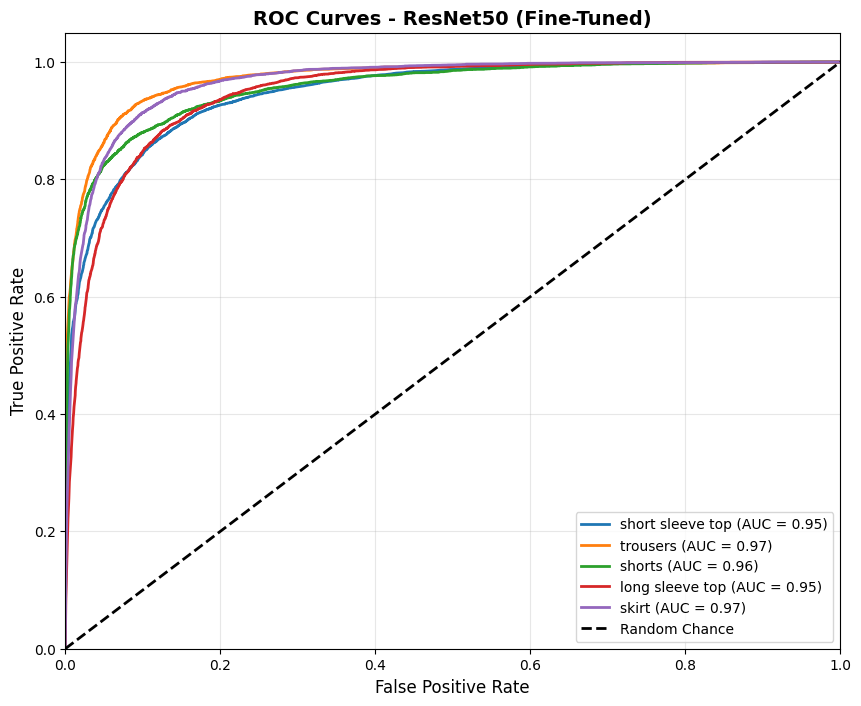


Evaluating ResNet50 (From Scratch)...


Running Inference: 100%|██████████| 371/371 [04:49<00:00,  1.28it/s]



--- Results for ResNet50 (From Scratch) ---
[short sleeve top] Precision: 0.8292 | Recall: 0.7775 | F1: 0.8025
[trousers] Precision: 0.8733 | Recall: 0.8434 | F1: 0.8581
[shorts] Precision: 0.5005 | Recall: 0.8631 | F1: 0.6336
[long sleeve top] Precision: 0.5797 | Recall: 0.7919 | F1: 0.6694
[skirt] Precision: 0.6372 | Recall: 0.8500 | F1: 0.7284

Macro-Averaged F1: 0.7384
Micro-Averaged F1: 0.7561
[short sleeve top] AUC: 0.8905
[trousers] AUC: 0.9531
[shorts] AUC: 0.9295
[long sleeve top] AUC: 0.8868
[skirt] AUC: 0.9142


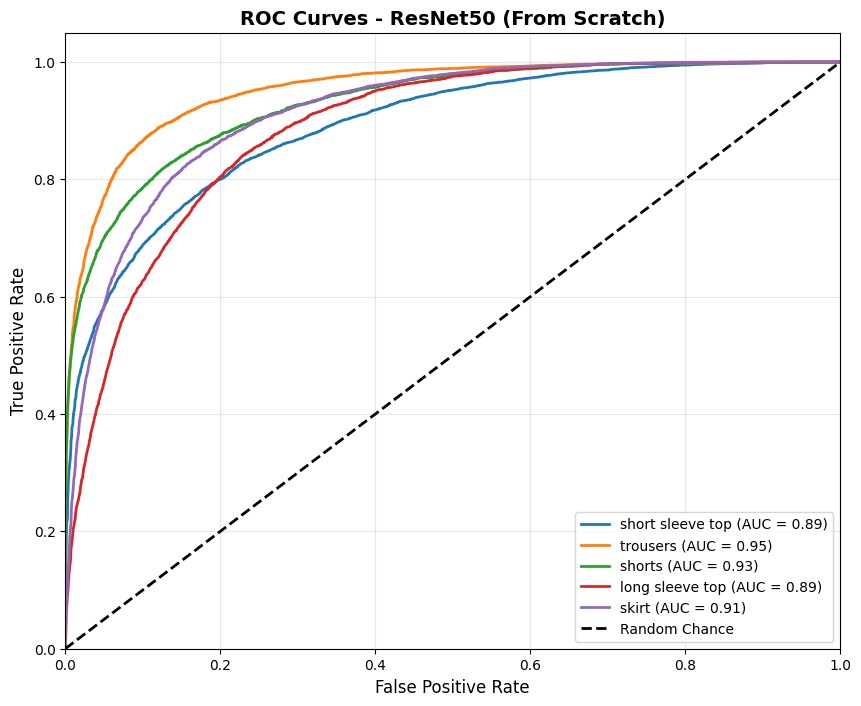

In [6]:
import os
import json
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --- 1. Validation Dataset Setup ---
class ValidationDataset(Dataset):
    def __init__(self, json_dir, image_dir, transform=None):
        self.json_dir = json_dir
        self.image_dir = image_dir
        self.transform = transform
        self.json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
        
        # Hardcode the exact order used during training
        self.top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.top_5_classes)}

    def __len__(self):
        return len(self.json_files)

    def __getitem__(self, idx):
        json_file = self.json_files[idx]
        img_file = json_file.replace('.json', '.jpg')
        
        img_path = os.path.join(self.image_dir, img_file)
        json_path = os.path.join(self.json_dir, json_file)
        
        # Open image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
            
        # Parse JSON for ground truth labels
        with open(json_path, 'r') as f:
            data = json.load(f)
            
        labels = [0.0] * 5
        for key, value in data.items():
            if key.startswith('item') and isinstance(value, dict):
                cat_name = value.get('category_name')
                if cat_name in self.class_to_idx:
                    labels[self.class_to_idx[cat_name]] = 1.0
                    
        return image, torch.tensor(labels, dtype=torch.float32)

# ResNet50 uses 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_dataset = ValidationDataset(
    json_dir="./trimmed_dataset/validation/annos", 
    image_dir="./trimmed_dataset/validation/image", 
    transform=transform
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f"Loaded {len(val_dataset)} validation images.")


# --- 2. ResNet50 Architecture Builders ---
def get_resnet50_finetune(num_classes=5):
    # Load pretrained weights skeleton
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # Replace the classification head
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet50_scratch(num_classes=5):
    # Load architecture with NO weights
    model = models.resnet50(weights=None)
    # Replace the classification head
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# --- 3. Evaluation Function ---
def evaluate_model(model, dataloader, device, model_name):
    print(f"\nEvaluating {model_name}...")
    model.eval()
    
    all_targets = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Running Inference"):
            images = images.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probabilities.extend(probs)
            all_predictions.extend(preds)
            all_targets.extend(labels.numpy())
            
    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    
    classes = val_dataset.top_5_classes
    
    # --- Metrics Calculation ---
    print(f"\n--- Results for {model_name} ---")
    
    precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average=None, zero_division=0)
    for i, cls in enumerate(classes):
        print(f"[{cls}] Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f}")
        
    _, _, macro_f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average='macro', zero_division=0)
    _, _, micro_f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average='micro', zero_division=0)
    print(f"\nMacro-Averaged F1: {macro_f1:.4f}")
    print(f"Micro-Averaged F1: {micro_f1:.4f}")
    
    # --- ROC Curves ---
    plt.figure(figsize=(10, 8))
    for i, cls in enumerate(classes):
        auc_score = roc_auc_score(all_targets[:, i], all_probabilities[:, i])
        print(f"[{cls}] AUC: {auc_score:.4f}")
        
        fpr, tpr, _ = roc_curve(all_targets[:, i], all_probabilities[:, i])
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc_score:.2f})")
        
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 4. Load Models and Run ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_and_eval_resnet(weights_path, model_name, mode):
    # Initialize ResNet50 Skeleton
    if mode == "finetune":
        model = get_resnet50_finetune()
    else:
        model = get_resnet50_scratch()
    
    # Safely load the dictionary we saved during training
    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict)
    
    model = model.to(device)
    
    # Evaluate
    evaluate_model(model, val_loader, device, model_name)
    
    # Clean up GPU memory
    del model
    torch.cuda.empty_cache()

# Execute ResNet models
try:
    # Make sure these paths point to where your ResNet .pth files actually are!
    load_and_eval_resnet("./ResNet/resnet50_TRUE_finetune_epoch_5.pth", "ResNet50 (Fine-Tuned)", "finetune")
    load_and_eval_resnet("./ResNet/resnet50_scratch_epoch_10.pth", "ResNet50 (From Scratch)", "scratch")
except FileNotFoundError as e:
    print(f"\nError: Could not find model weights. ({e})")

# Detection and Segmentation

## YOLO

### Under-sample main dataset for faster training

In [ ]:
import json
import random
from tqdm import tqdm
from collections import Counter

INPUT_JSON = "./master_train_annotations.json"
OUTPUT_JSON = "./balanced_train_annotations.json"

# Change this to 30625 for your lowest class, or use any other number lesser than it for faster training
TARGET_QUOTA = 20000 

print(f"Loading {INPUT_JSON}...")
with open(INPUT_JSON, 'r') as f:
    data = json.load(f)

image_paths = list(data.keys())
random.shuffle(image_paths) # Shuffle to ensure random sampling

balanced_data = {}
class_counts = Counter()
top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']

print(f"Sampling images to hit {TARGET_QUOTA} per class...")

for img_path in tqdm(image_paths):
    annotations = data[img_path]
    
    # Check which classes are in this image
    classes_in_image = set([anno['category_name'] for anno in annotations if anno['category_name'] in top_5_classes])
    
    # Check if this image helps us meet a quota that isn't full yet
    useful = False
    for cls in classes_in_image:
        if class_counts[cls] < TARGET_QUOTA:
            useful = True
            break
            
    # If useful, add the image and update our counts
    if useful:
        balanced_data[img_path] = annotations
        for cls in classes_in_image:
            class_counts[cls] += 1
            
    # Stop early if all quotas are met
    if all(class_counts[cls] >= TARGET_QUOTA for cls in top_5_classes):
        break

print("\n--- Final Balanced Counts ---")
for cls in top_5_classes:
    print(f"{cls}: {class_counts[cls]}")

print(f"\nTotal images retained: {len(balanced_data)}")

with open(OUTPUT_JSON, 'w') as f:
    json.dump(balanced_data, f)
    
print(f"Saved balanced dataset to: {OUTPUT_JSON}")

### 1) Convert to YOLO-Specific Inputs

In [ ]:
import os
import json
import shutil
from PIL import Image
from tqdm import tqdm

# 1. Training Sources
TRAIN_JSON = "./balanced_train_annotations.json" 
TRAIN_IMAGE_DIR = "./train/train/image"

# 2. Validation Sources
VAL_JSON_DIR = "./trimmed_dataset/validation/annos"
VAL_IMAGE_DIR = "./trimmed_dataset/validation/image"

# 3. YOLO Output Destination
YOLO_BASE_DIR = "./yolo_dataset_balanced"

# YOLO requires specific subdirectories
for split in ['train', 'val']:
    os.makedirs(os.path.join(YOLO_BASE_DIR, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_BASE_DIR, 'labels', split), exist_ok=True)

# Top 5 classes mapped to integers (0 to 4)
top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
class_to_idx = {cls: i for i, cls in enumerate(top_5_classes)}

# Helper Function to Process and Save YOLO Formats
def process_and_save_yolo(src_img_path, dest_img_path, dest_label_path, annotations_list):
    """Reads an image and its annotations, normalizes polygons, and saves to YOLO format."""
    if not os.path.exists(src_img_path):
        return
        
    try:
        with Image.open(src_img_path) as img:
            img_width, img_height = img.size
    except Exception as e:
        print(f"Error reading {src_img_path}: {e}")
        return
        
    # Copy image to YOLO directory
    shutil.copy2(src_img_path, dest_img_path)
    
    # Create the YOLO label .txt file
    with open(dest_label_path, 'w') as label_file:
        for anno in annotations_list:
            cat_name = anno.get('category_name')
            if cat_name not in class_to_idx:
                continue
                
            class_id = class_to_idx[cat_name]
            
            # Extract segmentation polygons. A single clothing item may contain more than one polygon.
            # We use the first/largest one for YOLO's single instance requirement.
            polygons = anno.get('segmentation', [])
            if not polygons or len(polygons[0]) < 6: # Needs at least 3 points (x,y) to form a polygon
                continue
                
            poly = polygons[0]
            
            # Normalize coordinates to [0, 1] for YOLO
            normalized_coords = []
            for j in range(0, len(poly), 2):
                x = max(0.0, min(1.0, poly[j] / img_width))
                y = max(0.0, min(1.0, poly[j+1] / img_height))
                normalized_coords.extend([f"{x:.6f}", f"{y:.6f}"])
                
            # Write line: class_id x1 y1 x2 y2 ...
            line = f"{class_id} " + " ".join(normalized_coords) + "\n"
            label_file.write(line)

# ==========================================
# 1. Process Training Set
# ==========================================
print("Processing Training Set...")
with open(TRAIN_JSON, 'r') as f:
    train_data = json.load(f)

for img_key, annotations in tqdm(train_data.items(), desc="Train Images"):
    img_filename = os.path.basename(img_key)
    
    src_img_path = os.path.join(TRAIN_IMAGE_DIR, img_filename)
    dest_img_path = os.path.join(YOLO_BASE_DIR, 'images', 'train', img_filename)
    dest_label_path = os.path.join(YOLO_BASE_DIR, 'labels', 'train', img_filename.replace('.jpg', '.txt'))
    
    process_and_save_yolo(src_img_path, dest_img_path, dest_label_path, annotations)

# ==========================================
# 2. Process Validation Set
# ==========================================
print("\nProcessing Validation Set...")
val_jsons = [f for f in os.listdir(VAL_JSON_DIR) if f.endswith('.json')]

for json_file in tqdm(val_jsons, desc="Val Images"):
    img_filename = json_file.replace('.json', '.jpg')
    
    src_img_path = os.path.join(VAL_IMAGE_DIR, img_filename)
    src_json_path = os.path.join(VAL_JSON_DIR, json_file)
    
    dest_img_path = os.path.join(YOLO_BASE_DIR, 'images', 'val', img_filename)
    dest_label_path = os.path.join(YOLO_BASE_DIR, 'labels', 'val', img_filename.replace('.jpg', '.txt'))
    
    if not os.path.exists(src_json_path):
        continue
        
    with open(src_json_path, 'r') as f:
        val_data = json.load(f)
        
    # The validation set has a dictionary structure ({"item1": {...}, "item2": {...}})
    # We convert it to a list of dictionaries to match the helper function's expected input
    val_annotations = [v for k, v in val_data.items() if k.startswith('item') and isinstance(v, dict)]
    
    process_and_save_yolo(src_img_path, dest_img_path, dest_label_path, val_annotations)

# ==========================================
# 3. Generate dataset.yaml
# ==========================================
yaml_content = f"""
path: {os.path.abspath(YOLO_BASE_DIR)}
train: images/train
val: images/val

names:
  0: short sleeve top
  1: trousers
  2: shorts
  3: long sleeve top
  4: skirt
"""
with open(os.path.join(YOLO_BASE_DIR, "dataset.yaml"), "w") as f:
    f.write(yaml_content)
    
print(f"\nSuccess! YOLO dataset perfectly aligned with custom directories at: {YOLO_BASE_DIR}")

### 2) Initialize and Train YOLO Model

In [ ]:
from ultralytics import YOLO
import torch

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

# 2. Initialize the YOLOv8 Segmentation Architecture
# This utilizes the YOLOv8 backbone  and a PAN neck.
model = YOLO('yolov8s-seg.pt')

# 3. Train the Model
print("\nStarting YOLO Training...")

results = model.train(
    data='./yolo_dataset_balanced/dataset.yaml', 
    epochs=5,                          
    imgsz=512, 
    workers=4,                         
    batch=12,
    device=0, 
    name='clothing_yolo_seg_balanced',           
    patience=5                          
)

print("\nTraining Complete! Best model weights saved in: runs/segment/clothing_yolo_seg_balanced/weights/best.pt")

### 3) Inference and Metrics

Forcing inference and tensor math on: cuda:0
Loading trained YOLO model...

--- 1. COCO mAP (Detection & Segmentation) ---
YOLOv8s-seg summary (fused): 86 layers, 11,781,535 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access  (ping: 0.60.2 ms, read: 86.242.5 MB/s, size: 41.1 KB)
val: Scanning C:\Users\Darsh Veer Singh\OneDrive - iiit-b\Sem 6\AID825 - Visual Recognition\Mini Project\yolo_dataset_balanced\labels\val.cache... 23741 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23741/23741 3.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1484/1484 6.8it/s 3:39<0.1ss
                   all      23741      38797       0.85      0.862      0.894      0.763      0.849      0.855      0.885      0.689
Speed: 2.3ms preprocess, 3.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Detection mAP@[0.5:0.95]:    0.7633
Segmentation mAP@[0.5:0.95]: 0.6892

--- 2. Calc

Processing Validation Images: 100%|██████████| 23741/23741 [14:29<00:00, 27.30it/s]



--- 3. Segmentation Performance ---
[short sleeve top] mIoU: 0.7371 | Dice (F1): 0.7822
[trousers] mIoU: 0.6751 | Dice (F1): 0.7347
[shorts] mIoU: 0.5738 | Dice (F1): 0.6183
[long sleeve top] mIoU: 0.5796 | Dice (F1): 0.6270
[skirt] mIoU: 0.6891 | Dice (F1): 0.7248

Macro-Averaged mIoU: 0.6509

--- 4. Detection ROC, AUC, and F1 ---
[short sleeve top] Detection F1-Score: 0.9141 | AUC: 0.9570
[trousers] Detection F1-Score: 0.9071 | AUC: 0.9597
[shorts] Detection F1-Score: 0.8467 | AUC: 0.9389
[long sleeve top] Detection F1-Score: 0.8422 | AUC: 0.9402
[skirt] Detection F1-Score: 0.8800 | AUC: 0.9495


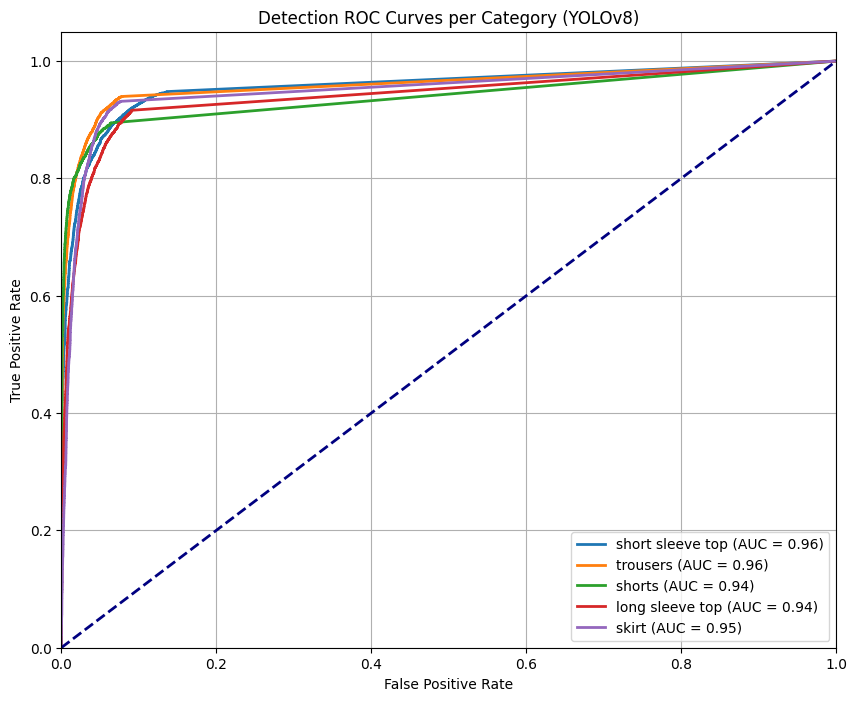

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc, f1_score
from tqdm import tqdm

MODEL_PATH = "runs/segment/clothing_yolo_seg_balanced/weights/best.pt" 
VAL_IMG_DIR = "./yolo_dataset_balanced/images/val"
VAL_LBL_DIR = "./yolo_dataset_balanced/labels/val"

CLASSES = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
NUM_CLASSES = len(CLASSES)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Forcing inference and tensor math on: {device}")

print("Loading trained YOLO model...")
model = YOLO(MODEL_PATH)

# ==========================================
# PART 1: Automated COCO mAP (GPU Accelerated)
# ==========================================
print("\n--- 1. COCO mAP (Detection & Segmentation) ---")
metrics = model.val(data='./yolo_dataset_balanced/dataset.yaml', split='val', plots=False, verbose=False, device=device)
print(f"Detection mAP@[0.5:0.95]:    {metrics.box.map:.4f}")
print(f"Segmentation mAP@[0.5:0.95]: {metrics.seg.map:.4f}")

# ==========================================
# PART 2: Custom mIoU, Dice, ROC, and AUC
# ==========================================
print("\n--- 2. Calculating Custom Pixel-Level Metrics ---")
ious = {i: [] for i in range(NUM_CLASSES)}
dices = {i: [] for i in range(NUM_CLASSES)}

y_true = []
y_scores = []

img_files = [f for f in os.listdir(VAL_IMG_DIR) if f.endswith('.jpg')]

for img_name in tqdm(img_files, desc="Processing Validation Images"):
    img_path = os.path.join(VAL_IMG_DIR, img_name)
    txt_name = img_name.replace('.jpg', '.txt')
    lbl_path = os.path.join(VAL_LBL_DIR, txt_name)
    
    # A. Read Image and Run GPU Inference
    img = cv2.imread(img_path)
    if img is None: continue
    H, W = img.shape[:2]
    
    # Force the prediction through the GPU
    results = model.predict(img, verbose=False, device=device)[0]
    
    # B. Parse Ground Truth Masks (Drawn on CPU via OpenCV)
    gt_masks = np.zeros((NUM_CLASSES, H, W), dtype=np.uint8)
    img_true_labels = [0] * NUM_CLASSES
    
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                img_true_labels[cls_id] = 1 
                
                coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
                coords[:, 0] *= W
                coords[:, 1] *= H
                poly = coords.astype(np.int32)
                cv2.fillPoly(gt_masks[cls_id], [poly], 1)
                
    # C. Parse Prediction Masks
    pred_masks = np.zeros((NUM_CLASSES, H, W), dtype=np.uint8)
    img_pred_scores = [0.0] * NUM_CLASSES
    
    if results.masks is not None:
        for poly_coords, cls_id, conf in zip(results.masks.xy, results.boxes.cls, results.boxes.conf):
            cls_id = int(cls_id.item())
            img_pred_scores[cls_id] = max(img_pred_scores[cls_id], conf.item()) 
            
            if len(poly_coords) > 2: 
                poly = np.array(poly_coords, dtype=np.int32)
                cv2.fillPoly(pred_masks[cls_id], [poly], 1)
                
    y_true.append(img_true_labels)
    y_scores.append(img_pred_scores)
    
    # D. Calculate IoU and Dice using GPU Tensor Math
    # Transfer the numpy arrays directly to the VRAM as boolean tensors
    gt_masks_gpu = torch.tensor(gt_masks, device=device, dtype=torch.bool)
    pred_masks_gpu = torch.tensor(pred_masks, device=device, dtype=torch.bool)
    
    for c in range(NUM_CLASSES):
        if img_true_labels[c] == 1 or img_pred_scores[c] > 0:
            intersection = torch.logical_and(gt_masks_gpu[c], pred_masks_gpu[c]).sum().item()
            union = torch.logical_or(gt_masks_gpu[c], pred_masks_gpu[c]).sum().item()
            
            iou = intersection / (union + 1e-6)
            
            gt_sum = gt_masks_gpu[c].sum().item()
            pred_sum = pred_masks_gpu[c].sum().item()
            dice = (2 * intersection) / (gt_sum + pred_sum + 1e-6)
            
            ious[c].append(iou)
            dices[c].append(dice)

# ==========================================
# PART 3: Final Aggregation and Reporting
# ==========================================
print("\n--- 3. Segmentation Performance ---")
macro_iou = 0
for c in range(NUM_CLASSES):
    cls_iou = np.mean(ious[c]) if ious[c] else 0.0
    cls_dice = np.mean(dices[c]) if dices[c] else 0.0
    macro_iou += cls_iou
    print(f"[{CLASSES[c]}] mIoU: {cls_iou:.4f} | Dice (F1): {cls_dice:.4f}")

print(f"\nMacro-Averaged mIoU: {macro_iou / NUM_CLASSES:.4f}")

print("\n--- 4. Detection ROC, AUC, and F1 ---")
y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_preds = (y_scores > 0.5).astype(int)

plt.figure(figsize=(10, 8))
for c in range(NUM_CLASSES):
    f1 = f1_score(y_true[:, c], y_preds[:, c], zero_division=0)
    fpr, tpr, _ = roc_curve(y_true[:, c], y_scores[:, c])
    roc_auc = auc(fpr, tpr)
    
    print(f"[{CLASSES[c]}] Detection F1-Score: {f1:.4f} | AUC: {roc_auc:.4f}")
    plt.plot(fpr, tpr, lw=2, label=f'{CLASSES[c]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Detection ROC Curves per Category (YOLOv8)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Mask R-CNN

### Creating Custom Dataset Class for R-CNN input

In [ ]:
import os
import json
import torch
import numpy as np
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

class ClothingMaskRCNNDataset(Dataset):
    def __init__(self, json_path, image_dir, transforms=None):
        """
        Custom Dataset for PyTorch Torchvision Mask R-CNN.
        """
        self.image_dir = image_dir
        self.transforms = transforms
        
        print(f"Loading annotations from {json_path}...")
        with open(json_path, 'r') as f:
            self.data = json.load(f)
            
        self.image_paths = list(self.data.keys())
        
        # Exact same mapping used in YOLO
        self.classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
        # Note: Mask R-CNN reserves label '0' for the background. 
        # So we shift our class IDs to start at 1
        self.class_to_idx = {cls: i + 1 for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        # 1. Load Image
        # Mask R-CNN expects images as FloatTensors scaled between 0 and 1
        img = Image.open(img_path).convert("RGB")
        img_width, img_height = img.size
        
        # 2. Parse Annotations
        annotations = self.data[img_path]
        
        boxes = []
        labels = []
        masks = []
        
        for anno in annotations:
            cat_name = anno.get('category_name')
            if cat_name not in self.class_to_idx:
                continue
                
            # Extract Polygon
            polygons = anno.get('segmentation', [])
            if not polygons or len(polygons[0]) < 6:
                continue
                
            poly = polygons[0]
            
            # Draw the binary mask using OpenCV
            mask = np.zeros((img_height, img_width), dtype=np.uint8)
            coords = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [coords], 1)
            
            # Extract Bounding Box [xmin, ymin, xmax, ymax]
            pos = np.where(mask)
            if len(pos[0]) == 0 or len(pos[1]) == 0:
                continue # Skip if mask is empty
                
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            
            # Sanity check to ensure box is valid
            if xmax <= xmin or ymax <= ymin:
                continue
                
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class_to_idx[cat_name])
            masks.append(mask)
            
        # 3. Convert everything to PyTorch Tensors
        # If an image has no valid bounding boxes, create empty tensors to prevent crashes
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, img_height, img_width), dtype=torch.uint8)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            masks = torch.tensor(np.array(masks), dtype=torch.uint8)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            
        # iscrowd tells the model if this is a single object or a cluster (always 0 for us)
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        
        # Combine into the exact dictionary structure required by Mask R-CNN
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = torch.tensor([idx])
        target["area"] = area
        target["iscrowd"] = iscrowd

        # Apply basic transform (Convert PIL image to PyTorch Tensor)
        if self.transforms is None:
            img = TF.to_tensor(img)

        return img, target

# Mask R-CNN requires a custom collate function because images have different numbers of bounding boxes
def collate_fn(batch):
    return tuple(zip(*batch))

# --- Testing the Dataset ---
# Point this to your actual balanced JSON and image directory
train_dataset = ClothingMaskRCNNDataset(
    json_path="./balanced_train_annotations.json", 
    image_dir="./train/train/image"
)

print(f"Successfully initialized Mask R-CNN Dataset with {len(train_dataset)} images.")

Loading annotations from ./balanced_train_annotations.json...
Successfully initialized Mask R-CNN Dataset with 71443 images.


### 1) Initialize R-CNN Model

In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_fast_mask_rcnn_model(num_classes):
    print("Loading ResNet-50 FPN backbone with 512px optimization...")
    
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=512, 
        max_size=512
    )

    # Replace Box Head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Replace Mask Head
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, 
        hidden_layer, 
        num_classes
    )

    return model

model = get_fast_mask_rcnn_model(num_classes=6)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading ResNet-50 FPN backbone with 512px optimization...


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(512,), max_size=512, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(inp

### 2) Training Loop

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

train_loader = DataLoader(
    train_dataset, 
    batch_size=6,         
    shuffle=True, 
    num_workers=0, 
    pin_memory=True,      
    collate_fn=collate_fn 
)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=0.0005)

scaler = torch.amp.GradScaler('cuda')

num_epochs = 5
print(f"\nStarting Fast Mask R-CNN Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model.train() 
    epoch_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for images, targets in progress_bar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        
        # Run the forward pass in 16-bit precision using AMP
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Scales the loss to prevent underflow, then backpropagates
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        # ----------------------
        
        epoch_loss += losses.item()
        progress_bar.set_postfix({'Total Loss': f"{losses.item():.4f}"})
        
    avg_loss = epoch_loss / len(train_loader)
    print(f"End of Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")
    
    torch.save(model.state_dict(), f"mask_rcnn_epoch_{epoch+1}.pth")
    torch.cuda.empty_cache()

print("\nTraining Complete! Best model saved as mask_rcnn_epoch_5.pth")


Starting Fast Mask R-CNN Training for 5 epochs...


Epoch 1/5: 100%|██████████| 11908/11908 [1:23:38<00:00,  2.37it/s, Total Loss=0.4075]


End of Epoch 1 | Average Loss: 0.3596


Epoch 2/5: 100%|██████████| 11908/11908 [1:18:26<00:00,  2.53it/s, Total Loss=0.1216]


End of Epoch 2 | Average Loss: 0.2921


...

End of Epoch 3 | Average Loss: 0.2666


Epoch 4/5: 100%|██████████| 11908/11908 [1:18:07<00:00,  2.54it/s, Total Loss=0.1499]


End of Epoch 4 | Average Loss: 0.2495


Epoch 5/5: 100%|██████████| 11908/11908 [1:18:56<00:00,  2.51it/s, Total Loss=0.2505]


End of Epoch 5 | Average Loss: 0.2378

Training Complete! Best model saved as mask_rcnn_epoch_5.pth


### 3) Evaluation Results

Initializing Validation Dataset...
Loading annotations from ./balanced_train_annotations.json...
Loading Trained Mask R-CNN Model...
Loading ResNet-50 FPN backbone with 512px optimization...

Running Inference and Calculating Metrics on GPU...


Evaluating: 100%|██████████| 35722/35722 [1:06:09<00:00,  9.00it/s]



          MASK R-CNN EVALUATION RESULTS        

COCO Detection mAP@[0.5:0.95]: 0.7960

--- Segmentation Performance ---
[short sleeve top] mIoU: 0.7043 | Dice (F1): 0.8265
[trousers] mIoU: 0.7422 | Dice (F1): 0.8520
[shorts] mIoU: 0.7625 | Dice (F1): 0.8652
[long sleeve top] mIoU: 0.6581 | Dice (F1): 0.7938
[skirt] mIoU: 0.7690 | Dice (F1): 0.8694

Macro-Averaged mIoU:  0.7272
Macro-Averaged Dice:  0.8414

--- Detection ROC, AUC, and F1 ---
[short sleeve top] Detection F1-Score: 0.8662 | AUC: 0.9722
[trousers] Detection F1-Score: 0.9143 | AUC: 0.9908
[shorts] Detection F1-Score: 0.9108 | AUC: 0.9830
[long sleeve top] Detection F1-Score: 0.8598 | AUC: 0.9573
[skirt] Detection F1-Score: 0.9034 | AUC: 0.9659


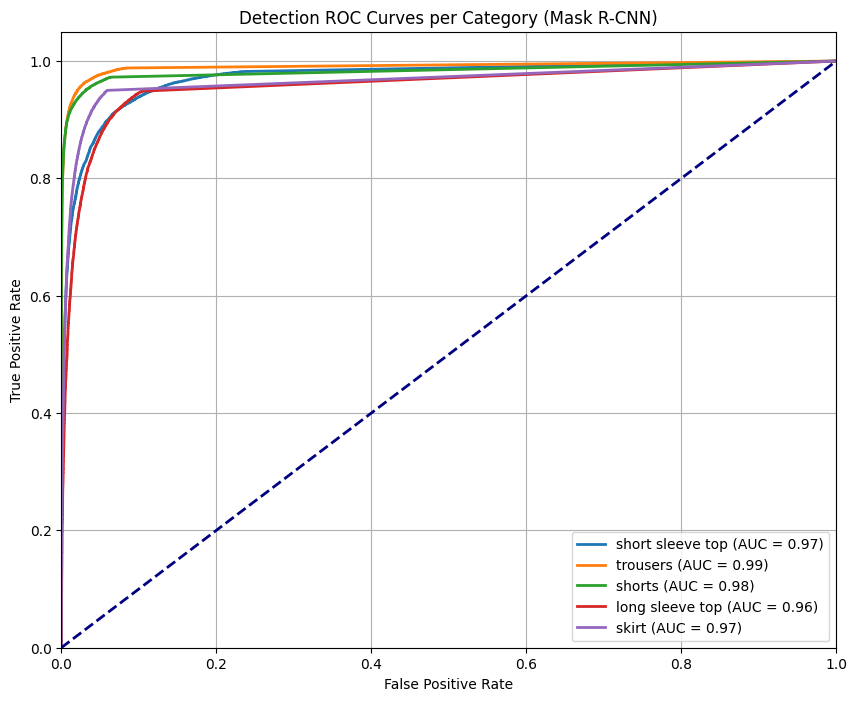

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm

VAL_JSON = "./balanced_train_annotations.json" 
VAL_IMG_DIR = "./trimmed_dataset/validation/image"

# Mask R-CNN classes (0 is background, 1-5 are clothing)
CLASSES = ['background', 'short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
NUM_CLASSES = 6 

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Initializing Validation Dataset...")
val_dataset = ClothingMaskRCNNDataset(VAL_JSON, VAL_IMG_DIR)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)

# Load trained model weights
print("Loading Trained Mask R-CNN Model...")
model = get_fast_mask_rcnn_model(NUM_CLASSES)
model.load_state_dict(torch.load("mask_rcnn_epoch_5.pth", map_location=device))
model.to(device)
model.eval() 

# --- Metric Trackers ---
# COCO mAP Tracker
map_metric = MeanAveragePrecision(iou_type="bbox", class_metrics=False).to(device)

# Pixel-level Trackers
total_intersections = {i: 0.0 for i in range(1, NUM_CLASSES)}
total_unions = {i: 0.0 for i in range(1, NUM_CLASSES)}
total_mask_pixels = {i: 0.0 for i in range(1, NUM_CLASSES)}

# Classification Trackers for ROC/AUC
y_true = []
y_scores = []

# --- Run Inference ---
print("\nRunning Inference and Calculating Metrics on GPU...")
with torch.no_grad(): # Prevent VRAM explosion during evaluation
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward Pass
        outputs = model(images)
        
        # A. Update COCO mAP Metric
        # Torchmetrics requires a specific list of dictionaries
        map_preds = [{"boxes": out["boxes"], "scores": out["scores"], "labels": out["labels"]} for out in outputs]
        map_targets = [{"boxes": t["boxes"], "labels": t["labels"]} for t in targets]
        map_metric.update(map_preds, map_targets)
        
        # B. Calculate Image-Level Metrics (mIoU, Dice, ROC)
        for i in range(len(images)):
            img_true_labels = [0] * NUM_CLASSES
            img_pred_scores = [0.0] * NUM_CLASSES
            
            gt = targets[i]
            pred = outputs[i]
            
            # Collapse instance masks into semantic masks per category for easy IoU calculation
            for c in range(1, NUM_CLASSES):
                # Ground Truth Mask for class 'c'
                gt_idx = (gt["labels"] == c)
                if gt_idx.any():
                    img_true_labels[c] = 1
                    gt_mask_c = gt["masks"][gt_idx].max(dim=0)[0] 
                else:
                    gt_mask_c = torch.zeros_like(images[i][0], dtype=torch.uint8, device=device)
                    
                # Predicted Mask for class 'c' (Filter by > 0.5 confidence and > 0.5 mask threshold)
                pred_idx = (pred["labels"] == c) & (pred["scores"] > 0.5)
                if pred_idx.any():
                    img_pred_scores[c] = pred["scores"][pred_idx].max().item() 
                    soft_masks = pred["masks"][pred_idx, 0] 
                    binary_masks = (soft_masks > 0.5).to(torch.uint8)
                    pred_mask_c = binary_masks.max(dim=0)[0] 
                else:
                    pred_mask_c = torch.zeros_like(images[i][0], dtype=torch.uint8, device=device)
                
                # Calculate Intersection and Union using GPU Tensor Math
                intersection = torch.logical_and(gt_mask_c, pred_mask_c).sum().item()
                union = torch.logical_or(gt_mask_c, pred_mask_c).sum().item()
                
                total_intersections[c] += intersection
                total_unions[c] += union
                total_mask_pixels[c] += (gt_mask_c.sum().item() + pred_mask_c.sum().item())
                
            y_true.append(img_true_labels)
            y_scores.append(img_pred_scores)

# --- 4. Final Aggregation and Reporting ---
print("\n=============================================")
print("          MASK R-CNN EVALUATION RESULTS        ")
print("=============================================\n")

# 1. COCO mAP
map_results = map_metric.compute()
print(f"COCO Detection mAP@[0.5:0.95]: {map_results['map'].item():.4f}\n")

# 2. Segmentation Metrics (mIoU & Dice)
print("--- Segmentation Performance ---")
macro_iou = 0.0
macro_dice = 0.0

for c in range(1, NUM_CLASSES):
    iou = total_intersections[c] / (total_unions[c] + 1e-6)
    dice = (2 * total_intersections[c]) / (total_mask_pixels[c] + 1e-6)
    
    macro_iou += iou
    macro_dice += dice
    print(f"[{CLASSES[c]}] mIoU: {iou:.4f} | Dice (F1): {dice:.4f}")

print(f"\nMacro-Averaged mIoU:  {macro_iou / 5:.4f}")
print(f"Macro-Averaged Dice:  {macro_dice / 5:.4f}\n")

# 3. Detection Metrics (ROC, AUC, F1)
print("--- Detection ROC, AUC, and F1 ---")
y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_preds = (y_scores > 0.5).astype(int)

plt.figure(figsize=(10, 8))
for c in range(1, NUM_CLASSES):
    f1 = f1_score(y_true[:, c], y_preds[:, c], zero_division=0)
    fpr, tpr, _ = roc_curve(y_true[:, c], y_scores[:, c])
    roc_auc = auc(fpr, tpr)
    
    print(f"[{CLASSES[c]}] Detection F1-Score: {f1:.4f} | AUC: {roc_auc:.4f}")
    plt.plot(fpr, tpr, lw=2, label=f'{CLASSES[c]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Detection ROC Curves per Category (Mask R-CNN)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## U-Net

### Creating a custom Dataset Class for Input

In [4]:
import os
import json
import torch
import numpy as np
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 768 # Upgraded resolution for better edge detection
BATCH_SIZE = 4 # Reduced to accommodate the larger 768x768 resolution

print("Loading dataset annotations...")
with open("./balanced_train_annotations.json", 'r') as f:
    train_data = json.load(f)
    
top_5_classes = ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
class_to_idx = {cls: i for i, cls in enumerate(top_5_classes)}
NUM_CLASSES = len(top_5_classes)
NUM_SEG_CLASSES = NUM_CLASSES + 1 # 0=bg, 1..5=clothing

# Albumentations Pipeline (identical spatial transforms for image and mask)
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.Rotate(limit=15, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.3),
    A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

class UNetSegDataset(Dataset):
    """
    Outputs:
      image: (3, H, W) float32
      mask:  (H, W) int64 (0=bg, 1-5=clothing classes)
    """
    def __init__(self, data_dict, image_dir, transform=None, img_size=IMG_SIZE):
        self.image_paths = list(data_dict.keys())
        self.data_dict = data_dict
        self.image_dir = image_dir
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def _build_semantic_mask(self, img_path, ih, iw):
        # 1-channel mask for multiclass segmentation
        mask = np.zeros((ih, iw), dtype=np.int32)
        annotations = self.data_dict[img_path]
        
        for anno in annotations:
            cat_name = anno.get('category_name')
            if cat_name not in class_to_idx:
                continue
                
            # Class labels 1 to 5 (0 is reserved for background)
            cls_label = class_to_idx[cat_name] + 1
            
            for poly in anno.get('segmentation', []):
                if len(poly) < 6:
                    continue
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                pts = np.clip(pts, [0, 0], [iw - 1, ih - 1])
                cv2.fillPoly(mask, [pts.astype(np.int32)], cls_label)
                
        return mask.astype(np.int64)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img_name = os.path.basename(img_path)
        full_img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = np.array(Image.open(full_img_path).convert('RGB'))
        except Exception:
            image = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        ih, iw = image.shape[:2]
        sem_mask = self._build_semantic_mask(img_path, ih, iw)

        if self.transform:
            out = self.transform(image=image, mask=sem_mask)
            image = out['image']
            sem_mask = out['mask'].long()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            sem_mask = torch.from_numpy(sem_mask).long()

        return image, sem_mask

# Initialize Dataset and DataLoader
train_dataset = UNetSegDataset(
    data_dict=train_data, 
    image_dir="./train/train/image", 
    transform=train_transforms
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

print(f"Successfully initialized U-Net Dataset with {len(train_dataset)} images (Resolution: {IMG_SIZE}x{IMG_SIZE}).")

Loading dataset annotations...
Successfully initialized U-Net Dataset with 71443 images (Resolution: 768x768).


c:\Users\Darsh Veer Singh\OneDrive - iiit-b\Sem 6\AID825 - Visual Recognition\Mini Project\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Darsh Veer Singh\AppData\Local\Temp\ipykernel_16584\3708352765.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.2),


### 2) Initialize U-Net Model

In [5]:
import segmentation_models_pytorch as smp

print("Building U-Net with pre-trained ResNet-34 backbone...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_SEG_CLASSES,       # 6 classes (0=bg, 1-5=clothing)
    activation=None,               # Raw logits output
    decoder_use_batchnorm=True
).to(device)

total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
print(f'Total params  : {total_params:,}')
print(f'Encoder params: {encoder_params:,} (ResNet-34, ImageNet pretrained)')
print(f'Decoder params: {total_params - encoder_params:,} (Randomly initialized)')

def freeze_encoder(m):
    for p in m.encoder.parameters():
        p.requires_grad = False
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'[Phase 1] Encoder FROZEN  — trainable: {trainable:,}')

def unfreeze_encoder(m):
    for p in m.encoder.parameters():
        p.requires_grad = True
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'[Phase 2] Encoder UNFROZEN — trainable: {trainable:,}')

# Start with Phase 1 (Frozen Encoder)
freeze_encoder(model)

Building U-Net with pre-trained ResNet-34 backbone...
Total params  : 24,437,094
Encoder params: 21,284,672 (ResNet-34, ImageNet pretrained)
Decoder params: 3,152,422 (Randomly initialized)
[Phase 1] Encoder FROZEN  — trainable: 3,152,422


### 3) Training Loop for U-Net

In [ ]:
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

EPOCHS = 5
ENCODER_LR = 2e-5  # 10x smaller to protect pretrained ImageNet weights
DECODER_LR = 2e-4  # Standard LR for the randomly initialized decoder

# --- 1. Define Loss Functions ---
ce_criterion = nn.CrossEntropyLoss() # Standard, equally-weighted CE

def dice_loss(logits, targets, smooth=1.0):
    C = logits.size(1)
    probs = F.softmax(logits, dim=1)
    targets_oh = F.one_hot(targets, C).permute(0, 3, 1, 2).float()
    inter = (probs * targets_oh).sum(dim=(2, 3))
    union = probs.sum(dim=(2, 3)) + targets_oh.sum(dim=(2, 3))
    dice_per_class = (2 * inter + smooth) / (union + smooth)
    return 1 - dice_per_class[:, 1:].mean()

def combined_loss(logits, targets, alpha=0.5): # Use 0.5 for equal balance
    return alpha * ce_criterion(logits, targets) + (1 - alpha) * dice_loss(logits, targets)

# --- 2. Differential Optimizer Setup ---
# Instead of freezing, we use different learning rates for different parts of the model
optimizer = optim.AdamW([
    {'params': model.encoder.parameters(),           'lr': ENCODER_LR},
    {'params': model.decoder.parameters(),           'lr': DECODER_LR},
    {'params': model.segmentation_head.parameters(), 'lr': DECODER_LR},
], weight_decay=1e-4)

scaler = torch.amp.GradScaler('cuda')

# --- 3. The 5-Epoch Training Loop ---
print(f"\nStarting U-Net Training for exactly {EPOCHS} epochs...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True, dynamic_ncols=True)
    
    for images, masks in progress_bar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # AMP for speed and memory efficiency
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss = combined_loss(logits, masks)
            
        scaler.scale(loss).backward()
        
        # Gradient clipping to prevent sudden spikes from destroying weights
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})
        
    avg_loss = running_loss / len(train_dataset)
    tqdm.write(f"End of Epoch {epoch} | Avg Loss: {avg_loss:.4f}")
    
    # Save checkpoint
    torch.save(model.state_dict(), f"unet_resnet34_epoch_{epoch}.pth")
    
    gc.collect()
    torch.cuda.empty_cache()
    
print("\nTraining Complete!")


Starting U-Net Training for exactly 5 epochs...


Epoch 1/5: 100%|██████████| 17861/17861 [1:42:40<00:00,  2.90it/s, Loss=0.5123]


End of Epoch 1 | Avg Loss: 0.6821


Epoch 2/5: 100%|██████████| 17861/17861 [1:54:36<00:00,  2.60it/s, Loss=0.5073]  


End of Epoch 2 | Avg Loss: 0.6380


### 4) Post-Processing, Inference and Metrics

Loading Trained U-Net Model...

Running Inference and Post-Processing on GPU/CPU...


Evaluating: 100%|██████████| 71443/71443 [18:24<00:00, 64.67it/s] 



            U-NET EVALUATION RESULTS           

COCO Detection mAP@[0.5:0.95]: 0.0001

--- Segmentation Performance ---
[short sleeve top] mIoU: 0.0727 | Dice (F1): 0.1355
[trousers] mIoU: 0.0359 | Dice (F1): 0.0692
[shorts] mIoU: 0.0151 | Dice (F1): 0.0298
[long sleeve top] mIoU: 0.0421 | Dice (F1): 0.0808
[skirt] mIoU: 0.0307 | Dice (F1): 0.0595

Macro-Averaged mIoU:  0.0393
Macro-Averaged Dice:  0.0750

--- Detection ROC, AUC, and F1 ---
[short sleeve top] Detection F1-Score: 0.5974 | AUC: 0.5016
[trousers] Detection F1-Score: 0.4425 | AUC: 0.4893
[shorts] Detection F1-Score: 0.2737 | AUC: 0.5022
[long sleeve top] Detection F1-Score: 0.3637 | AUC: 0.4693
[skirt] Detection F1-Score: 0.2956 | AUC: 0.4992


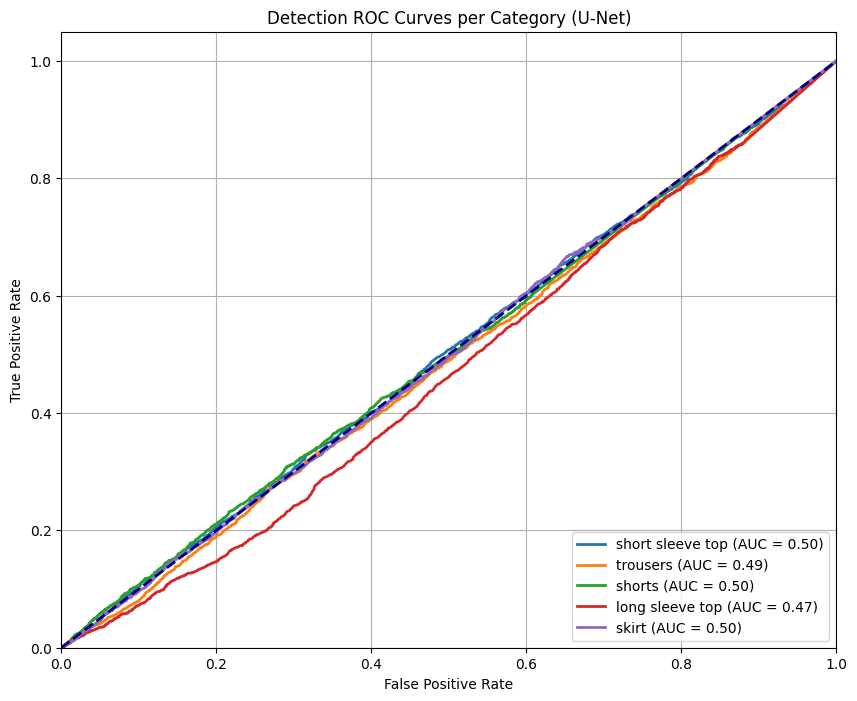

In [2]:
import os
import json
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from torchvision import transforms as T
from PIL import Image
from sklearn.metrics import roc_curve, auc, f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm

# --- 1. Setup & Configuration ---
VAL_JSON = "./balanced_train_annotations.json" # Replace with your validation JSON path
VAL_IMG_DIR = "./trimmed_dataset/validation/image"

CLASSES = ['background', 'short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
NUM_CLASSES = len(CLASSES)
IMG_SIZE = (768, 768)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Re-initialize and load the trained model
print("Loading Trained U-Net Model...")
model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=6, activation=None)
model.load_state_dict(torch.load("unet_resnet34_epoch_5.pth", map_location=device))
model.to(device)
model.eval()

# Validation transforms
transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Metric Trackers ---
map_metric = MeanAveragePrecision(iou_type="bbox", class_metrics=False).to(device)

total_intersections = {i: 0.0 for i in range(1, NUM_CLASSES)}
total_unions = {i: 0.0 for i in range(1, NUM_CLASSES)}
total_mask_pixels = {i: 0.0 for i in range(1, NUM_CLASSES)}

y_true = []
y_scores = []

# Load Ground Truth JSON
with open(VAL_JSON, 'r') as f:
    val_data = json.load(f)

class_to_idx = {cls: i for i, cls in enumerate(CLASSES) if cls != 'background'}

# --- 3. Run Inference & Post-Processing ---
print("\nRunning Inference and Post-Processing on GPU/CPU...")

with torch.no_grad():
    for img_path in tqdm(val_data.keys(), desc="Evaluating"):
        img_name = os.path.basename(img_path)
        full_img_path = os.path.join(VAL_IMG_DIR, img_name)
        
        if not os.path.exists(full_img_path):
            continue
            
        # A. Prepare Image
        img_pil = Image.open(full_img_path).convert("RGB")
        orig_w, orig_h = img_pil.size
        img_tensor = transform(img_pil).unsqueeze(0).to(device)
        
        # B. U-Net Forward Pass (Wrapped in autocast to match training!)
        with torch.amp.autocast('cuda'):
            logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)[0] # Shape: [6, H, W]
        
        # C. Ground Truth Parsing
        gt_boxes = []
        gt_labels = []
        gt_masks = np.zeros((NUM_CLASSES, IMG_SIZE[0], IMG_SIZE[1]), dtype=np.uint8)
        img_true_labels = [0] * NUM_CLASSES
        
        for anno in val_data[img_path]:
            cat_name = anno.get('category_name')
            if cat_name not in class_to_idx: continue
            
            c = class_to_idx[cat_name]
            img_true_labels[c] = 1
            
            poly = anno.get('segmentation', [[0]*6])[0]
            scaled_poly = []
            for j in range(0, len(poly), 2):
                x = max(0, min(IMG_SIZE[0]-1, (poly[j] / orig_w) * IMG_SIZE[0]))
                y = max(0, min(IMG_SIZE[1]-1, (poly[j+1] / orig_h) * IMG_SIZE[1]))
                scaled_poly.append([x, y])
                
            coords = np.array(scaled_poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(gt_masks[c], [coords], 1)
            
            x_coords = coords[:, 0]
            y_coords = coords[:, 1]
            gt_boxes.append([x_coords.min(), y_coords.min(), x_coords.max(), y_coords.max()])
            gt_labels.append(c)
            
        # D. POST-PROCESSING (Speckle Destruction + AUC Fix)
        pred_boxes = []
        pred_labels = []
        pred_scores = []
        img_pred_scores = [0.0] * NUM_CLASSES
        pred_masks = np.zeros((NUM_CLASSES, IMG_SIZE[0], IMG_SIZE[1]), dtype=np.uint8)
        
        probs_np = probs.cpu().numpy() # [6, H, W]
        pred_class_map = np.argmax(probs_np, axis=0) # [H, W]
        
        for c in range(1, NUM_CLASSES):
            class_mask = (pred_class_map == c).astype(np.uint8)
            pred_masks[c] = class_mask
            
            if class_mask.sum() == 0:
                continue
            
            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(class_mask, connectivity=8)
            class_max_score = 0.0 # Track the highest confident blob for this class
            
            for i in range(1, num_labels): # Skip 0 (background)
                x, y, w, h, area = stats[i]
                
                # THE FIX: Kills speckle noise from flat probabilities!
                if area < 400: 
                    continue 
                
                xmin, ymin, xmax, ymax = x, y, x + w, y + h
                
                # Blob score is the mean probability of its pixels
                component_mask = (labels == i)
                score = probs_np[c][component_mask].mean()
                
                class_max_score = max(class_max_score, float(score))
                
                pred_boxes.append([xmin, ymin, xmax, ymax])
                pred_labels.append(c)
                pred_scores.append(float(score))
                
            # THE AUC FIX: Image gets the score of its best blob (0.0 if no blobs survived)
            img_pred_scores[c] = class_max_score 
                
        y_true.append(img_true_labels)
        y_scores.append(img_pred_scores)
        
        # E. Update Torchmetrics mAP
        if len(gt_boxes) > 0 and len(pred_boxes) > 0:
            target = [{"boxes": torch.tensor(gt_boxes, dtype=torch.float32).to(device), 
                       "labels": torch.tensor(gt_labels, dtype=torch.int64).to(device)}]
            preds = [{"boxes": torch.tensor(pred_boxes, dtype=torch.float32).to(device), 
                      "scores": torch.tensor(pred_scores, dtype=torch.float32).to(device), 
                      "labels": torch.tensor(pred_labels, dtype=torch.int64).to(device)}]
            map_metric.update(preds, target)
            
        # F. Calculate Image-Level mIoU and Dice
        for c in range(1, NUM_CLASSES):
            intersection = np.logical_and(gt_masks[c], pred_masks[c]).sum()
            union = np.logical_or(gt_masks[c], pred_masks[c]).sum()
            
            total_intersections[c] += intersection
            total_unions[c] += union
            total_mask_pixels[c] += (gt_masks[c].sum() + pred_masks[c].sum())
            
# --- 4. Final Aggregation and Reporting ---
print("\n=============================================")
print("            U-NET EVALUATION RESULTS           ")
print("=============================================\n")

# 1. COCO mAP
map_results = map_metric.compute()
print(f"COCO Detection mAP@[0.5:0.95]: {map_results['map'].item():.4f}\n")

# 2. Segmentation Metrics
print("--- Segmentation Performance ---")
macro_iou = 0.0
macro_dice = 0.0

for c in range(1, NUM_CLASSES):
    iou = total_intersections[c] / (total_unions[c] + 1e-6)
    dice = (2 * total_intersections[c]) / (total_mask_pixels[c] + 1e-6)
    
    macro_iou += iou
    macro_dice += dice
    print(f"[{CLASSES[c]}] mIoU: {iou:.4f} | Dice (F1): {dice:.4f}")

print(f"\nMacro-Averaged mIoU:  {macro_iou / 5:.4f}")
print(f"Macro-Averaged Dice:  {macro_dice / 5:.4f}\n")

# 3. Detection ROC/AUC
print("--- Detection ROC, AUC, and F1 ---")
y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_preds = (y_scores > 0.5).astype(int)

plt.figure(figsize=(10, 8))
for c in range(1, NUM_CLASSES):
    f1 = f1_score(y_true[:, c], y_preds[:, c], zero_division=0)
    fpr, tpr, _ = roc_curve(y_true[:, c], y_scores[:, c])
    roc_auc = auc(fpr, tpr)
    
    print(f"[{CLASSES[c]}] Detection F1-Score: {f1:.4f} | AUC: {roc_auc:.4f}")
    plt.plot(fpr, tpr, lw=2, label=f'{CLASSES[c]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Detection ROC Curves per Category (U-Net)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Inference

## Efficient-Net B50

Loading EfficientNet-B2...


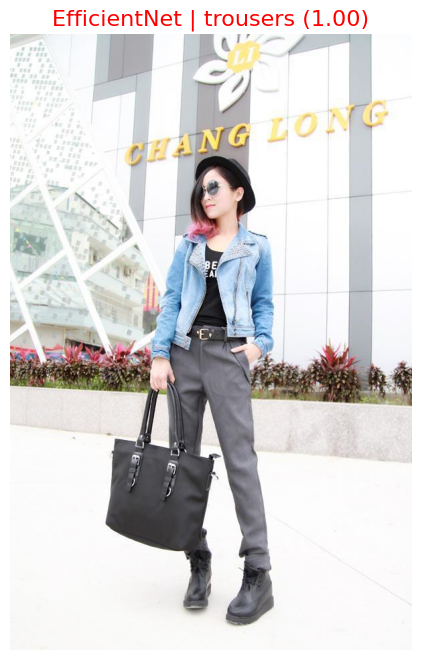


--- JSON OUTPUT ---
{
    "057163.jpg": {
        "EfficientNet": {
            "label": 1,
            "confidence": 0.9999997615814209
        }
    }
}


In [11]:
import os
import random
import json
import gc
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# --- Configuration ---
TEST_IMG_DIR = r"test/test/image"  # Adjust if your path is slightly different
LABEL_MAP = {0: "short sleeve top", 1: "trousers", 2: "shorts", 3: "long sleeve top", 4: "skirt"}

def test_efficientnet():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # 1. Load Model
    print("Loading EfficientNet-B2...")
    model = models.efficientnet_b2(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 5)
    model.load_state_dict(torch.load("efficientnet_finetune.pth", map_location=device))
    model.to(device)
    model.eval()

    # 2. Pick Random Image
    images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    img_name = random.choice(images)
    img_path = os.path.join(TEST_IMG_DIR, img_name)

    # 3. Run Inference
    transform = T.Compose([
        T.Resize((260, 260)), # B2 uses 260x260
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)
        
    label_idx = int(pred_idx.item())
    confidence = float(conf.item())
    
    # 4. Format JSON
    final_json = {
        img_name: {
            "EfficientNet": {
                "label": label_idx,
                "confidence": confidence
            }
        }
    }
    
    # 5. Display Image & Print Output
    plt.figure(figsize=(8, 8))
    plt.imshow(img_pil)
    plt.axis('off')
    plt.title(f"EfficientNet | {LABEL_MAP[label_idx]} ({confidence:.2f})", fontsize=16, color='red')
    plt.show()
    
    print("\n--- JSON OUTPUT ---")
    print(json.dumps(final_json, indent=4))
    
    # 6. Cleanup
    del model, img_tensor, outputs
    gc.collect()
    torch.cuda.empty_cache()

test_efficientnet()

## Yolo-V8

Loading YOLOv8...


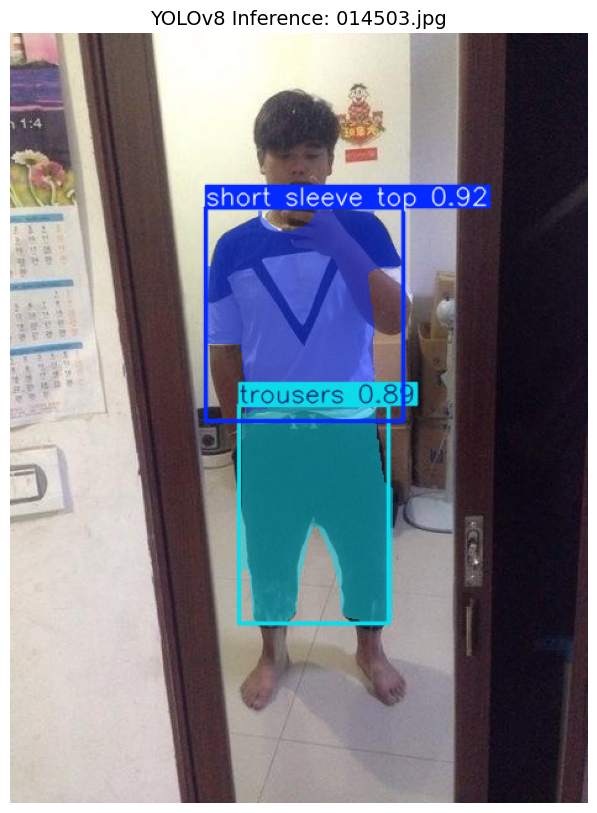


--- JSON OUTPUT ---
{
    "014503.jpg": {
        "YOLOv8": [
            {
                "label": 0,
                "confidence": 0.9237797260284424,
                "bbox": [
                    158.7366485595703,
                    141.51768493652344,
                    318.7445983886719,
                    314.4033508300781
                ]
            },
            {
                "label": 1,
                "confidence": 0.8854126334190369,
                "bbox": [
                    185.96726989746094,
                    301.2842102050781,
                    306.56719970703125,
                    478.1834411621094
                ]
            }
        ]
    }
}


In [12]:
import os
import random
import json
import gc
import torch
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

TEST_IMG_DIR = r"test/test/image"

def test_yolo():
    # 1. Load Model
    print("Loading YOLOv8...")
    model = YOLO("runs/segment/clothing_yolo_seg_balanced/weights/best.pt")

    # 2. Pick Random Image
    images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    img_name = random.choice(images)
    img_path = os.path.join(TEST_IMG_DIR, img_name)

    # 3. Run Inference
    results = model.predict(img_path, conf=0.5, verbose=False)[0]
    
    predictions = []
    if results.masks is not None:
        for box, mask, cls, conf in zip(results.boxes.xyxy, results.masks.xy, results.boxes.cls, results.boxes.conf):
            predictions.append({
                "label": int(cls.item()), 
                "confidence": float(conf.item()),
                "bbox": box.tolist(),
            })
            
    final_json = {img_name: {"YOLOv8": predictions}}

    # 4. Display Image using YOLO's native plotter
    plotted_img = results.plot() # Returns BGR array
    plotted_img_rgb = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(plotted_img_rgb)
    plt.axis('off')
    plt.title(f"YOLOv8 Inference: {img_name}", fontsize=14)
    plt.show()
    
    # 5. Print JSON
    print("\n--- JSON OUTPUT ---")
    print(json.dumps(final_json, indent=4))
    
    # 6. Cleanup
    del model, results
    gc.collect()
    torch.cuda.empty_cache()

test_yolo()

## Mask R-CNN

Loading Mask R-CNN...


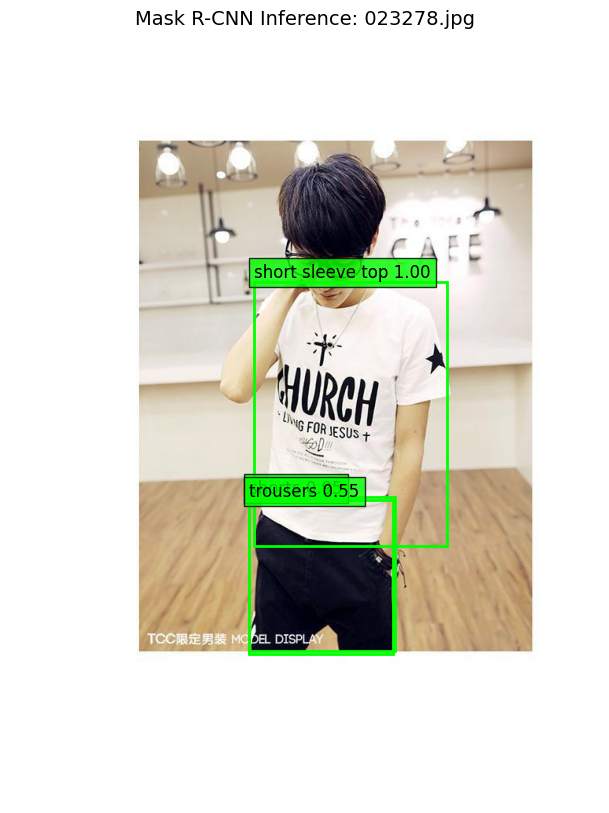


--- JSON OUTPUT ---
{
    "023278.jpg": {
        "Mask_RCNN": [
            {
                "label": 0,
                "confidence": 0.9972135424613953,
                "bbox": [
                    310.2093505859375,
                    315.8117370605469,
                    556.2476806640625,
                    652.3698120117188
                ]
            },
            {
                "label": 2,
                "confidence": 0.9491895437240601,
                "bbox": [
                    304.2349548339844,
                    590.2634887695312,
                    489.5333251953125,
                    786.5897216796875
                ]
            },
            {
                "label": 1,
                "confidence": 0.553043007850647,
                "bbox": [
                    303.7389831542969,
                    594.4592895507812,
                    487.39422607421875,
                    789.8645629882812
                ]
            }
        ]
    }
}

In [1]:
import os
import random
import json
import gc
import torch
import torchvision

# --- THE NUCLEAR BUG FIX ---
# Force the attribute onto the main module
torchvision._is_tracing = torch.jit.is_tracing

# Force the attribute directly into the specific sub-module that is crashing
import torchvision.ops.boxes as boxes
boxes.torchvision._is_tracing = torch.jit.is_tracing
# ---------------------------

import torchvision.transforms.functional as TF
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

TEST_IMG_DIR = r"test/test/image"
LABEL_MAP = {0: "short sleeve top", 1: "trousers", 2: "shorts", 3: "long sleeve top", 4: "skirt"}

def test_mask_rcnn():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # 1. Load Model
    print("Loading Mask R-CNN...")
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None, min_size=512, max_size=512)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 6)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, 6)
    
    model.load_state_dict(torch.load("mask_rcnn_epoch_5.pth", map_location=device))
    model.to(device)
    model.eval()

    # 2. Pick Random Image
    images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    img_name = random.choice(images)
    img_path = os.path.join(TEST_IMG_DIR, img_name)

    # 3. Run Inference
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = TF.to_tensor(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor)[0]
        
    predictions = []
    keep = output['scores'] > 0.5
    pred_boxes = output['boxes'][keep].cpu().numpy()
    pred_labels = output['labels'][keep].cpu().numpy()
    pred_scores = output['scores'][keep].cpu().numpy()
    
    # 4. Setup Plotting
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_pil)
    ax.axis('off')
    ax.set_title(f"Mask R-CNN Inference: {img_name}", fontsize=14)
    
    for i in range(len(pred_boxes)):
        xmin, ymin, xmax, ymax = pred_boxes[i]
        label_idx = int(pred_labels[i]) - 1 # SHIFT 1-5 to 0-4
        conf = pred_scores[i]
        
        predictions.append({
            "label": label_idx,
            "confidence": float(conf),
            "bbox": [float(xmin), float(ymin), float(xmax), float(ymax)]
        })
        
        # Draw Bounding Box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        # Draw Label Text
        ax.text(xmin, ymin - 5, f"{LABEL_MAP[label_idx]} {conf:.2f}", color='black', fontsize=12, bbox=dict(facecolor='lime', alpha=0.8))
        
    plt.show()

    final_json = {img_name: {"Mask_RCNN": predictions}}
    print("\n--- JSON OUTPUT ---")
    print(json.dumps(final_json, indent=4))
    
    # 5. Cleanup
    del model, img_tensor, output
    gc.collect()
    torch.cuda.empty_cache()

test_mask_rcnn()

## U-Net

Loading U-Net...


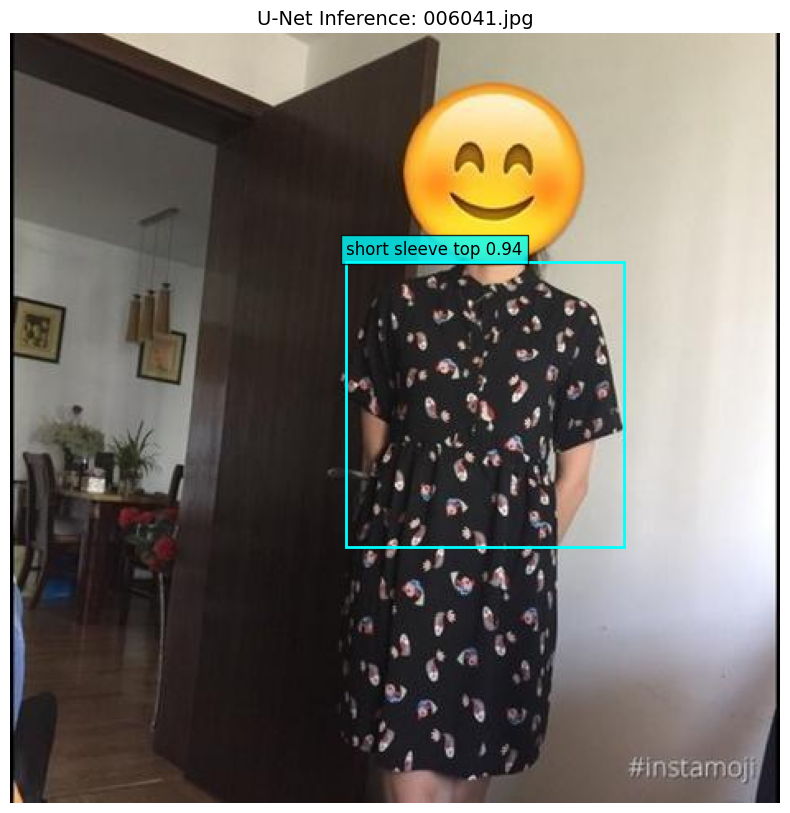


--- JSON OUTPUT ---
{
    "006041.jpg": {
        "UNet": [
            {
                "label": 0,
                "confidence": 0.9393406510353088,
                "bbox": [
                    203.8359375,
                    138.9375,
                    372.9375,
                    311.6953125
                ]
            }
        ]
    }
}


In [ ]:
import torch
import torchvision.transforms.functional as TF
import os
import random
import json
import gc
import cv2
import numpy as np
import segmentation_models_pytorch as smp
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

TEST_IMG_DIR = r"test/test/image"
LABEL_MAP = {0: "short sleeve top", 1: "trousers", 2: "shorts", 3: "long sleeve top", 4: "skirt"}

def test_unet():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    IMG_SIZE = (512, 512)
    
    # 1. Load Model
    print("Loading U-Net...")
    model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=6, activation=None)
    model.load_state_dict(torch.load("unet_resnet34_epoch_5.pth", map_location=device))
    model.to(device)
    model.eval()

    # 2. Pick Random Image
    images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    img_name = random.choice(images)
    img_path = os.path.join(TEST_IMG_DIR, img_name)

    # 3. Run Inference
    unet_transform = T.Compose([
        T.Resize(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_pil = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img_pil.size
    img_tensor = unet_transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()
        
    # 4. Post-Processing & Plotting Setup
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_pil)
    ax.axis('off')
    ax.set_title(f"U-Net Inference: {img_name}", fontsize=14)
    
    predictions = []
    
    for c in range(1, 6):
        class_mask = (probs[c] > 0.5).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(class_mask, connectivity=8)
        
        for i in range(1, num_labels):
            x, y, w, h, area = stats[i]
            if area < 50: continue 
                
            xmin = (x / IMG_SIZE[0]) * orig_w
            ymin = (y / IMG_SIZE[1]) * orig_h
            xmax = ((x + w) / IMG_SIZE[0]) * orig_w
            ymax = ((y + h) / IMG_SIZE[1]) * orig_h
            
            score = probs[c][labels == i].mean()
            label_idx = c - 1 # SHIFT 1-5 to 0-4
            
            predictions.append({
                "label": label_idx,
                "confidence": float(score),
                "bbox": [float(xmin), float(ymin), float(xmax), float(ymax)]
            })
            
            # Draw Bounding Box
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='cyan', facecolor='none')
            ax.add_patch(rect)
            # Draw Label Text
            ax.text(xmin, ymin - 5, f"{LABEL_MAP[label_idx]} {score:.2f}", color='black', fontsize=12, bbox=dict(facecolor='cyan', alpha=0.8))
            
    plt.show()

    final_json = {img_name: {"UNet": predictions}}
    print("\n--- JSON OUTPUT ---")
    print(json.dumps(final_json, indent=4))
    
    # 5. Cleanup
    del model, img_tensor, logits
    gc.collect()
    torch.cuda.empty_cache()

test_unet()